In [ ]:
!apt-get -qq install imagemagick
!pip -q install scikit-learn --upgrade

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm
import seaborn as sns
import itertools
from mpl_toolkits.mplot3d import Axes3D
from matplotlib.lines import Line2D
from IPython.display import Image
from scipy.spatial.distance import cdist

# Pyswarms solves the PSO https://pyswarms.readthedocs.io/en/latest/
try:
  import pyswarms as ps
except ModuleNotFoundError:
  !pip -q install pyswarms
  import pyswarms as ps
from pyswarms.utils.plotters import plot_cost_history, plot_contour, plot_surface
from pyswarms.utils.plotters.formatters import Animator, Designer, Mesher

from sklearn.ensemble import RandomForestRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error
from sklearn.model_selection import train_test_split

%matplotlib inline

E: Failed to fetch http://archive.ubuntu.com/ubuntu/pool/main/d/djvulibre/libdjvulibre-text_3.5.27.1-8ubuntu0.2_all.deb  404  Not Found [IP: 91.189.88.152 80]
E: Failed to fetch http://archive.ubuntu.com/ubuntu/pool/main/d/djvulibre/libdjvulibre21_3.5.27.1-8ubuntu0.2_amd64.deb  404  Not Found [IP: 91.189.88.152 80]
E: Unable to fetch some archives, maybe run apt-get update or try with --fix-missing?
     |████████████████████████████████| 22.3MB 1.4MB/s 
     |████████████████████████████████| 112kB 4.2MB/s 


# Data from PSO paper

In [ ]:
data = pd.read_csv("/content/drive/MyDrive/pso_data.csv", decimal=',', index_col=0)
columns_x = data.columns[data.columns != 'RK']
columns_y = data.columns[data.columns == 'RK']
data = data.apply(pd.to_numeric)
data['TC-min'] = - data['TC-min']
data['TC peak'] = - data['TC peak']
data_train, data_test = train_test_split(data, train_size=30, random_state=11)
data_train

,PSD-10,Mois,DF * 10^-4,TC-min,TC-max,TC peak,4SA,PSD-90,PSD-50,Sinter temp.,K,D-50,RK
42,0.51,0.01,31,-74.8,50.1,-5.6,3.0,1.87,0.97,1293,11.170,0.929,18.901
12,0.41,0.02,30,-74.0,43.5,-6.5,3.2,2.15,0.95,1283,10.797,0.843,17.292
7,0.43,0.06,29,-74.3,49.3,-7.4,3.0,1.97,0.92,1286,10.268,0.854,17.153
4,0.43,0.04,37,-73.8,44.5,-7.2,3.0,2.06,0.95,1292,10.345,0.910,16.188
20,0.46,0.05,29,-74.9,46.1,-6.5,3.0,1.93,0.94,1284,11.003,0.830,16.935
41,0.51,0.08,36,-74.8,47.3,-5.3,2.8,1.86,0.98,1266,10.858,1.008,17.747
21,0.43,0.08,39,-75.0,43.8,-5.7,3.1,2.01,0.94,1270,11.117,0.908,18.218
37,0.48,0.04,25,-76.4,59.8,-7.0,3.1,1.97,0.97,1293,11.804,0.873,19.840
22,0.46,0.01,35,-74.0,43.9,-6.8,3.1,1.93,0.94,1292,10.479,0.948,18.181
6,0.45,0.06,30,-74.5,47.5,-7.2,3.1,1.97,0.94,1282,10.806,0.905,16.642


# Tests

7.650518534711755 || 2.4222222222222225


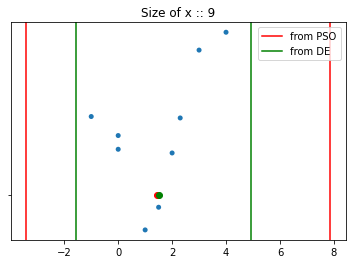

5.882748794601619 || 3.0357142857142856


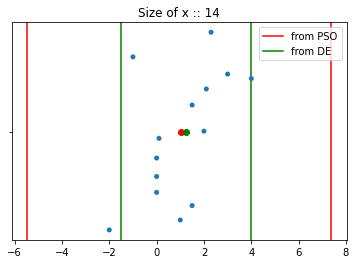

4.512926064587707 || 2.6521739130434785


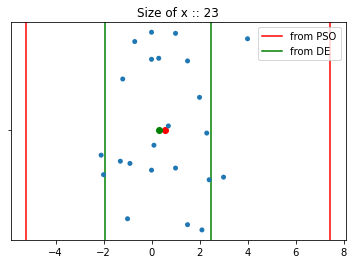

In [ ]:
x = np.array([1,2,-1,0,0,1.5,4,3,2.3])
CL = x.mean()
N_L = np.count_nonzero(x < CL)
N_U = np.count_nonzero(x > CL)
sk_L = N_L / (N_L + N_U + 1)
sk_U = N_U / (N_L + N_U + 1)
LB = CL - 1/sk_U * (CL - x.min())
UB = CL + 1/sk_L * (x.max() - CL)
CL2 = np.median(x)
S_x = np.sum((x - x.mean())**2) / (x.shape[0] - 1)
#print(f"S :: {S_x} | var :: {x.var()}")
print(f"{np.sqrt(-2*S_x/N_L * np.log(10**-20))} || {(CL - x.min())}")
LB2 = CL2 - sk_L * np.sqrt(-2*S_x/N_L * np.log(10**-20))
UB2 = CL2 + sk_U * np.sqrt(-2*S_x/N_U * np.log(10**-20))
sns.stripplot(x=x)
plt.scatter(CL, 0, marker='o', c='r')
plt.axvline(LB, c='r', label='from PSO')
plt.axvline(UB, c='r')
plt.scatter(CL2, 0, marker='o', c='g')
plt.axvline(LB2, c='g', label='from DE')
plt.axvline(UB2, c='g')
plt.title(f"Size of x :: {x.shape[0]}")
plt.legend()
plt.show()
####################################################
x = np.array([1,2,-1,0,0,1.5,4,3,2.3, 0.1, 2.1, -2, 1.5,0])
CL = x.mean()
N_L = np.count_nonzero(x < CL)
N_U = np.count_nonzero(x > CL)
sk_L = N_L / (N_L + N_U + 1)
sk_U = N_U / (N_L + N_U + 1)
LB = CL - 1/sk_U * (CL - x.min())
UB = CL + 1/sk_L * (x.max() - CL)
CL2 = np.median(x)
S_x = np.sum((x - x.mean())**2) / (x.shape[0] - 1)
#print(f"S :: {S_x} | var :: {x.var()}")
print(f"{np.sqrt(-2*S_x/N_L * np.log(10**-20))} || {(CL - x.min())}")
LB2 = CL2 - sk_L * np.sqrt(-2*S_x/N_L * np.log(10**-20))
UB2 = CL2 + sk_U * np.sqrt(-2*S_x/N_U * np.log(10**-20))
sns.stripplot(x=x)
plt.scatter(CL, 0, marker='o', c='r')
plt.axvline(LB, c='r', label='from PSO')
plt.axvline(UB, c='r')
plt.scatter(CL2, 0, marker='o', c='g')
plt.axvline(LB2, c='g', label='from DE')
plt.axvline(UB2, c='g')
plt.title(f"Size of x :: {x.shape[0]}")
plt.legend()
plt.show()
#####################################################
x = np.array([1,2,-1,0,0,1.5,4,3,2.3, 0.1, 2.1, -2, 1.5,0,1,2.4,0.7,-1.2,-1.3,-0.7,0.3,-2.1,-0.9])
CL = x.mean()
N_L = np.count_nonzero(x < CL)
N_U = np.count_nonzero(x > CL)
sk_L = N_L / (N_L + N_U + 1)
sk_U = N_U / (N_L + N_U + 1)
LB = CL - 1/sk_U * (CL - x.min())
UB = CL + 1/sk_L * (x.max() - CL)
CL2 = np.median(x)
S_x = np.sum((x - x.mean())**2) / (x.shape[0] - 1)
#print(f"S :: {S_x} | var :: {x.var()}")
print(f"{np.sqrt(-2*S_x/N_L * np.log(10**-20))} || {(CL - x.min())}")
LB2 = CL2 - sk_L * np.sqrt(-2*S_x/N_L * np.log(10**-20))
UB2 = CL2 + sk_U * np.sqrt(-2*S_x/N_U * np.log(10**-20))
sns.stripplot(x=x)
plt.scatter(CL, 0, marker='o', c='r')
plt.axvline(LB, c='r', label='from PSO')
plt.axvline(UB, c='r')
plt.scatter(CL2, 0, marker='o', c='g')
plt.axvline(LB2, c='g', label='from DE')
plt.axvline(UB2, c='g')
plt.title(f"Size of x :: {x.shape[0]}")
plt.legend()
plt.show()

0.05642617139797006 || 0.05340909090909102


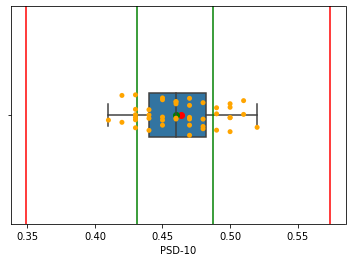

0.045536421931445005 || 0.035227272727272746


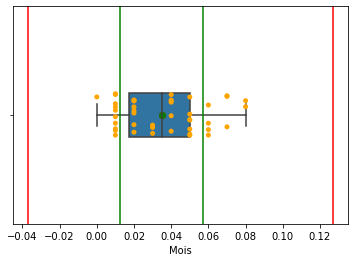

10.43225537277612 || 9.75


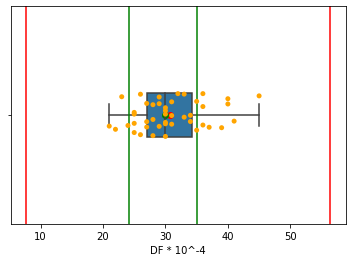

1.4971447668453965 || 1.7454545454545496


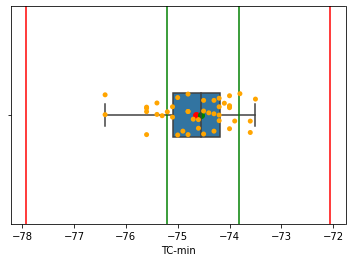

10.29522556415992 || 8.22727272727272


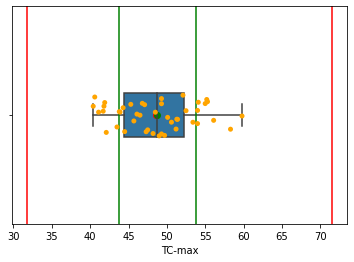

1.7379095453858913 || 2.463636363636362


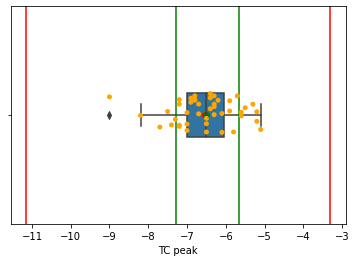

0.3030359602794594 || 0.4136363636363636


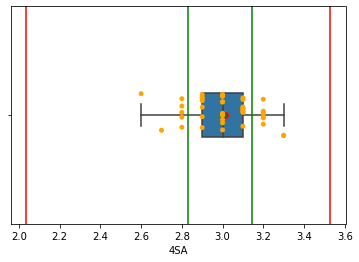

0.17785480734997847 || 0.1452272727272721


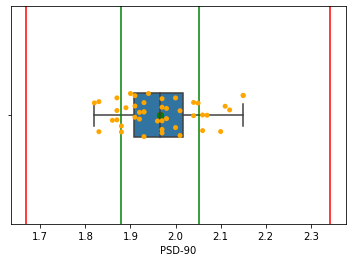

0.0402980821085836 || 0.03568181818181804


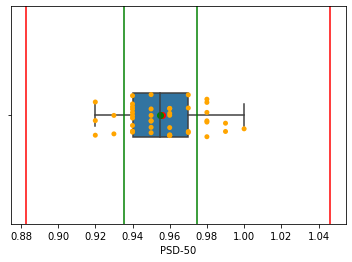

22.65309896088695 || 20.15909090909099


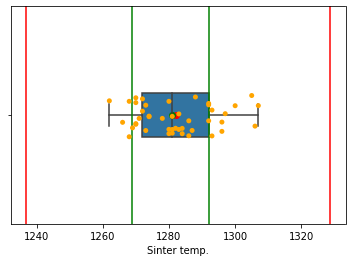

0.9900452577047842 || 0.7617272727272706


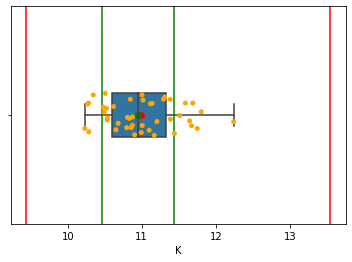

0.11756897442916703 || 0.09204545454545454


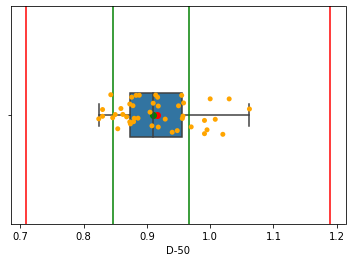

In [ ]:
for attr in columns_x:
  sns.boxplot(x=attr, data=data_train, width=.2)
  sns.stripplot(x=attr, data=data_train, color='orange')
  x = data_train[attr]
  CL = x.mean()
  N_L = np.count_nonzero(x < CL)
  N_U = np.count_nonzero(x > CL)
  sk_L = N_L / (N_L + N_U + 1)
  sk_U = N_U / (N_L + N_U + 1)
  LB = CL - 1/sk_U * (CL - x.min())
  UB = CL + 1/sk_L * (x.max() - CL)
  CL2 = x.median()
  S_x = np.sum((x - x.mean())**2) / (x.shape[0] - 1)
  #print(f"S :: {S_x} | var :: {x.var()}")
  print(f"{np.sqrt(-2*S_x/N_L * np.log(10**-20))} || {(CL - x.min())}")
  LB2 = CL2 - sk_L * np.sqrt(-2*S_x/N_L * np.log(10**-20))
  UB2 = CL2 + sk_U * np.sqrt(-2*S_x/N_U * np.log(10**-20))
  plt.scatter(CL, 0, marker='o', c='r')
  plt.axvline(LB, c='r')
  plt.axvline(UB, c='r')
  plt.scatter(CL2, 0, marker='o', c='g')
  plt.axvline(LB2, c='g')
  plt.axvline(UB2, c='g')
  plt.show()

# Normalize

In [ ]:
data_test = data_test.copy()
data_train = data_train.copy()
data_test.loc(axis=1)[columns_y] = data_test["RK"].apply(lambda x: (x - data["RK"].min())/(data["RK"].max() - data["RK"].min()))
data_train.loc(axis=1)[columns_y] = data_train["RK"].apply(lambda x: (x - data["RK"].min())/(data["RK"].max() - data["RK"].min()))

# RF

In [ ]:
number_new_samples = 100
desired_fitness = 10**-6
RF = RandomForestRegressor(n_estimators=100, max_features=3, max_depth=3)
RF.fit(data_train.loc(axis=1)[columns_x], data_train['RK'])

RandomForestRegressor(max_depth=3, max_features=3)

In [ ]:
########### Sanity check
test_prediction = RF.predict(data_test.loc(axis=1)[columns_x])
train_prediction = RF.predict(data_train.loc(axis=1)[columns_x])
print(f"{np.array(data_test.loc(axis=1)[columns_y])} || {test_prediction}")
print(f"MSE :: {mean_squared_error(data_test.loc(axis=1)[columns_y], test_prediction)}")
print(f"RMSE :: {np.sqrt(mean_squared_error(data_test.loc(axis=1)[columns_y], test_prediction))}")
print(f"MAPE :: {mean_absolute_percentage_error(data_test.loc(axis=1)[columns_y], test_prediction)}")
print(f"MSE :: {mean_squared_error(data_train.loc(axis=1)[columns_y], train_prediction)}")
print(f"RMSE :: {np.sqrt(mean_squared_error(data_train.loc(axis=1)[columns_y], train_prediction))}")
print(f"MAPE :: {mean_absolute_percentage_error(data_train.loc(axis=1)[columns_y], train_prediction)}")

[[17.687]
 [17.388]
 [20.23 ]
 [20.164]
 [17.112]
 [20.156]
 [16.606]
 [17.577]
 [16.681]
 [16.64 ]
 [17.286]
 [17.187]
 [18.092]
 [18.527]] || [17.59630298 18.35669677 18.45368808 17.95078283 16.86860633 18.19208557
 17.85404484 17.15536499 18.18785281 18.3228141  17.57528093 18.07916036
 17.27759892 17.79490564]
MSE :: 1.5595085386399663
RMSE :: 1.2488028421812494
MAPE :: 0.05813187083296282
MSE :: 0.20030178423337874
RMSE :: 0.4475508733466831
MAPE :: 0.021342087066341872


# KNeighbors

In [ ]:
number_new_samples = 100
desired_fitness = 10**-6
RF = KNeighborsRegressor()
RF.fit(data_train.loc(axis=1)[columns_x], data_train['RK'])

KNeighborsRegressor()

In [ ]:
########### Sanity check
test_prediction = RF.predict(data_test.loc(axis=1)[columns_x])
print(f"{np.array(data_test.loc(axis=1)[columns_y])} || {test_prediction}")
print(f"MSE :: {mean_squared_error(data_test.loc(axis=1)[columns_y], test_prediction)}")
print(f"RMSE :: {np.sqrt(mean_squared_error(data_test.loc(axis=1)[columns_y], test_prediction))}")
print(f"MAPE :: {mean_absolute_percentage_error(data_test.loc(axis=1)[columns_y], test_prediction)}")

[[17.687]
 [17.388]
 [20.23 ]
 [20.164]
 [17.112]
 [20.156]
 [16.606]
 [17.577]
 [16.681]
 [16.64 ]
 [17.286]
 [17.187]
 [18.092]
 [18.527]] || [16.9108 17.4252 17.4634 17.946  17.9188 17.4108 17.7914 17.7914 17.9876
 17.6956 18.2972 17.5622 17.8562 17.7914]
MSE :: 1.9569402885714282
RMSE :: 1.3989068191167804
MAPE :: 0.059609993216756085


# DE

In [ ]:
RF.fit(data_train.loc(axis=1)[columns_x], data_train['RK'])
########### DE
verbose = False
m = data_train.shape[0]/10
CL = data_train.loc(axis=1)[columns_x].median() #np.mean(data_train.loc(axis=1)[columns_x])
N_L = np.count_nonzero(data_train.loc(axis=1)[columns_x] < CL, axis=0)
N_U = np.count_nonzero(data_train.loc(axis=1)[columns_x] > CL, axis=0)
print(f"N_L :: {N_L} | N_U :: {N_U}")
LS = N_L / (N_L + N_U + m)
RS = N_U / (N_L + N_U + m)
S_x = np.sum((data_train.loc(axis=1)[columns_x] - CL)**2, axis=0) / (data_train.shape[0]-1)
#print(S_x)
LB = CL - LS * np.sqrt(-2*S_x/N_L * np.log(10**-20))
UB = CL + RS * np.sqrt(-2*S_x/N_U * np.log(10**-20))
#LB = np.maximum(LB, 0)
LB = np.minimum(LB, np.min(data_train.loc(axis=1)[columns_x], axis=0))
UB = np.maximum(UB, np.max(data_train.loc(axis=1)[columns_x], axis=0))
print(f"UB (from DE) :\n{UB}")
print(f"LB (from DE) :\n{LB}")
# DE
def f(x):
  if not LB.equals(np.minimum(LB, x)):
    return np.inf
  if not UB.equals(np.maximum(UB, x)):
    return np.inf
  y = data_train['RK']
  if verbose: print(f"x :: {x}")
  return np.min( np.abs((y - RF.predict(np.array(x).reshape(1, -1))) / y))

# def f(x):
#   n = data_train.shape[1]
#   #print(1/n * np.sum(np.min(np.absolute(data_train - x))))
#   return 1/n * np.sum(np.min(np.absolute(data_train - x))) #np.min(1/n * np.sum(np.absolute(data_train - x), axis=1))

print(f"Init:")
M = number_new_samples # number of data to produce
data_new = pd.DataFrame(columns=columns_x)
for i in tqdm(range(M)):
  new_x = []
  for attr in columns_x:
    new_x.append(LB[attr] + np.random.uniform() * (UB[attr] - LB[attr]))
  new_data = pd.DataFrame(np.array(new_x).reshape(1, -1), columns=columns_x)
  data_new = data_new.append(new_data, ignore_index=True)
if verbose: print(data_new.head())
print(f"Mutation, Crossover and Selection:")
count = 0
for g in tqdm(range(50)): # iterations
  fitness = 0
  for i in range(data_new.shape[0]):
    # Mutation
    F = 1.2#0.6 # scaling factor between [0,2]
    parents = data_new.loc[np.random.randint(0, data_new.shape[0], 3), :]
    p1 = parents.iloc[0]
    p2 = parents.iloc[1]
    p3 = parents.iloc[2]
    h = p1 + F * (p2 - p3)
    # Crossover
    P_cr = 0.7 # probability of crossover
    v_x = []
    for attr in columns_x:
      v_x.append(h[attr] if np.random.uniform() <= P_cr else data_new.loc[i, attr])
    v = pd.DataFrame(np.array(v_x).reshape(1, -1), columns=columns_x)
    # Selection
    if f(v.loc[0, :]) < f(data_new.loc[i, :]):
      for attr in columns_x:
        data_new.at[i, attr] = v[attr]
    fitness += f(data_new.loc[i, :])
  if fitness < 10**-3:
    break

data_new['RK'] = RF.predict(np.array(data_new[columns_x]))
data_new

N_L :: [18 22 19 22 22 20 14 22 22 20 22 22] | N_U :: [21 22 19 22 22 21 19 22 22 21 22 22]
UB (from DE) :
PSD-10             0.520
Mois               0.080
DF * 10^-4        45.000
TC-min           -73.500
TC-max            59.800
TC peak           -5.100
4SA                3.300
PSD-90             2.150
PSD-50             1.000
Sinter temp.    1307.000
K                 12.242
D-50               1.062
dtype: float64
LB (from DE) :
PSD-10             0.410
Mois               0.000
DF * 10^-4        21.000
TC-min           -76.400
TC-max            40.400
TC peak           -9.000
4SA                2.600
PSD-90             1.820
PSD-50             0.920
Sinter temp.    1262.000
K                 10.232
D-50               0.824
dtype: float64
Init:



Mutation, Crossover and Selection:


,PSD-10,Mois,DF * 10^-4,TC-min,TC-max,TC peak,4SA,PSD-90,PSD-50,Sinter temp.,K,D-50,RK
0,0.424534,0.050992,34.193642,-74.974889,54.772041,-5.516138,2.677012,2.125325,0.989495,1299.386510,10.555182,0.970910,19.05609
1,0.493057,0.039038,42.335964,-75.149105,42.563486,-8.818178,3.140259,1.924202,0.930890,1270.082554,11.295133,0.977993,17.22843
2,0.492869,0.041976,23.231254,-74.194701,44.884660,-8.707304,3.174173,1.850270,0.946540,1294.282454,10.567126,1.013649,17.33350
3,0.498169,0.008329,39.210334,-74.032555,40.611605,-6.830759,3.299804,2.057312,0.922951,1301.917117,10.285577,0.890289,17.45028
4,0.422867,0.047971,31.488215,-74.728455,59.342253,-5.525617,2.716240,2.108030,0.933034,1293.822625,10.518382,0.920085,18.82622
...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,0.492643,0.060404,34.040166,-74.424247,50.859805,-5.980453,3.209610,2.071893,0.941531,1270.780250,10.536896,0.999998,17.43992
96,0.424198,0.017351,35.249649,-75.840769,49.649650,-6.427759,2.756225,2.125031,0.953894,1303.751438,11.023909,0.890611,17.63325
97,0.412809,0.019139,22.155353,-75.473789,43.375067,-5.216630,2.610301,1.984183,0.929866,1268.628807,12.131726,0.991707,17.41680
98,0.453468,0.040604,23.449163,-75.075146,57.718348,-5.595344,3.061506,1.880323,0.939906,1284.937690,12.207327,0.905242,18.95461


In [ ]:
data_new_train = data_train.append(data_new)
data_new_train['Type'] = np.concatenate((np.full((data_train.shape[0]), "Raw samples"), np.full((data_new.shape[0]), "DEVSG samples")), axis=0)
#TODO

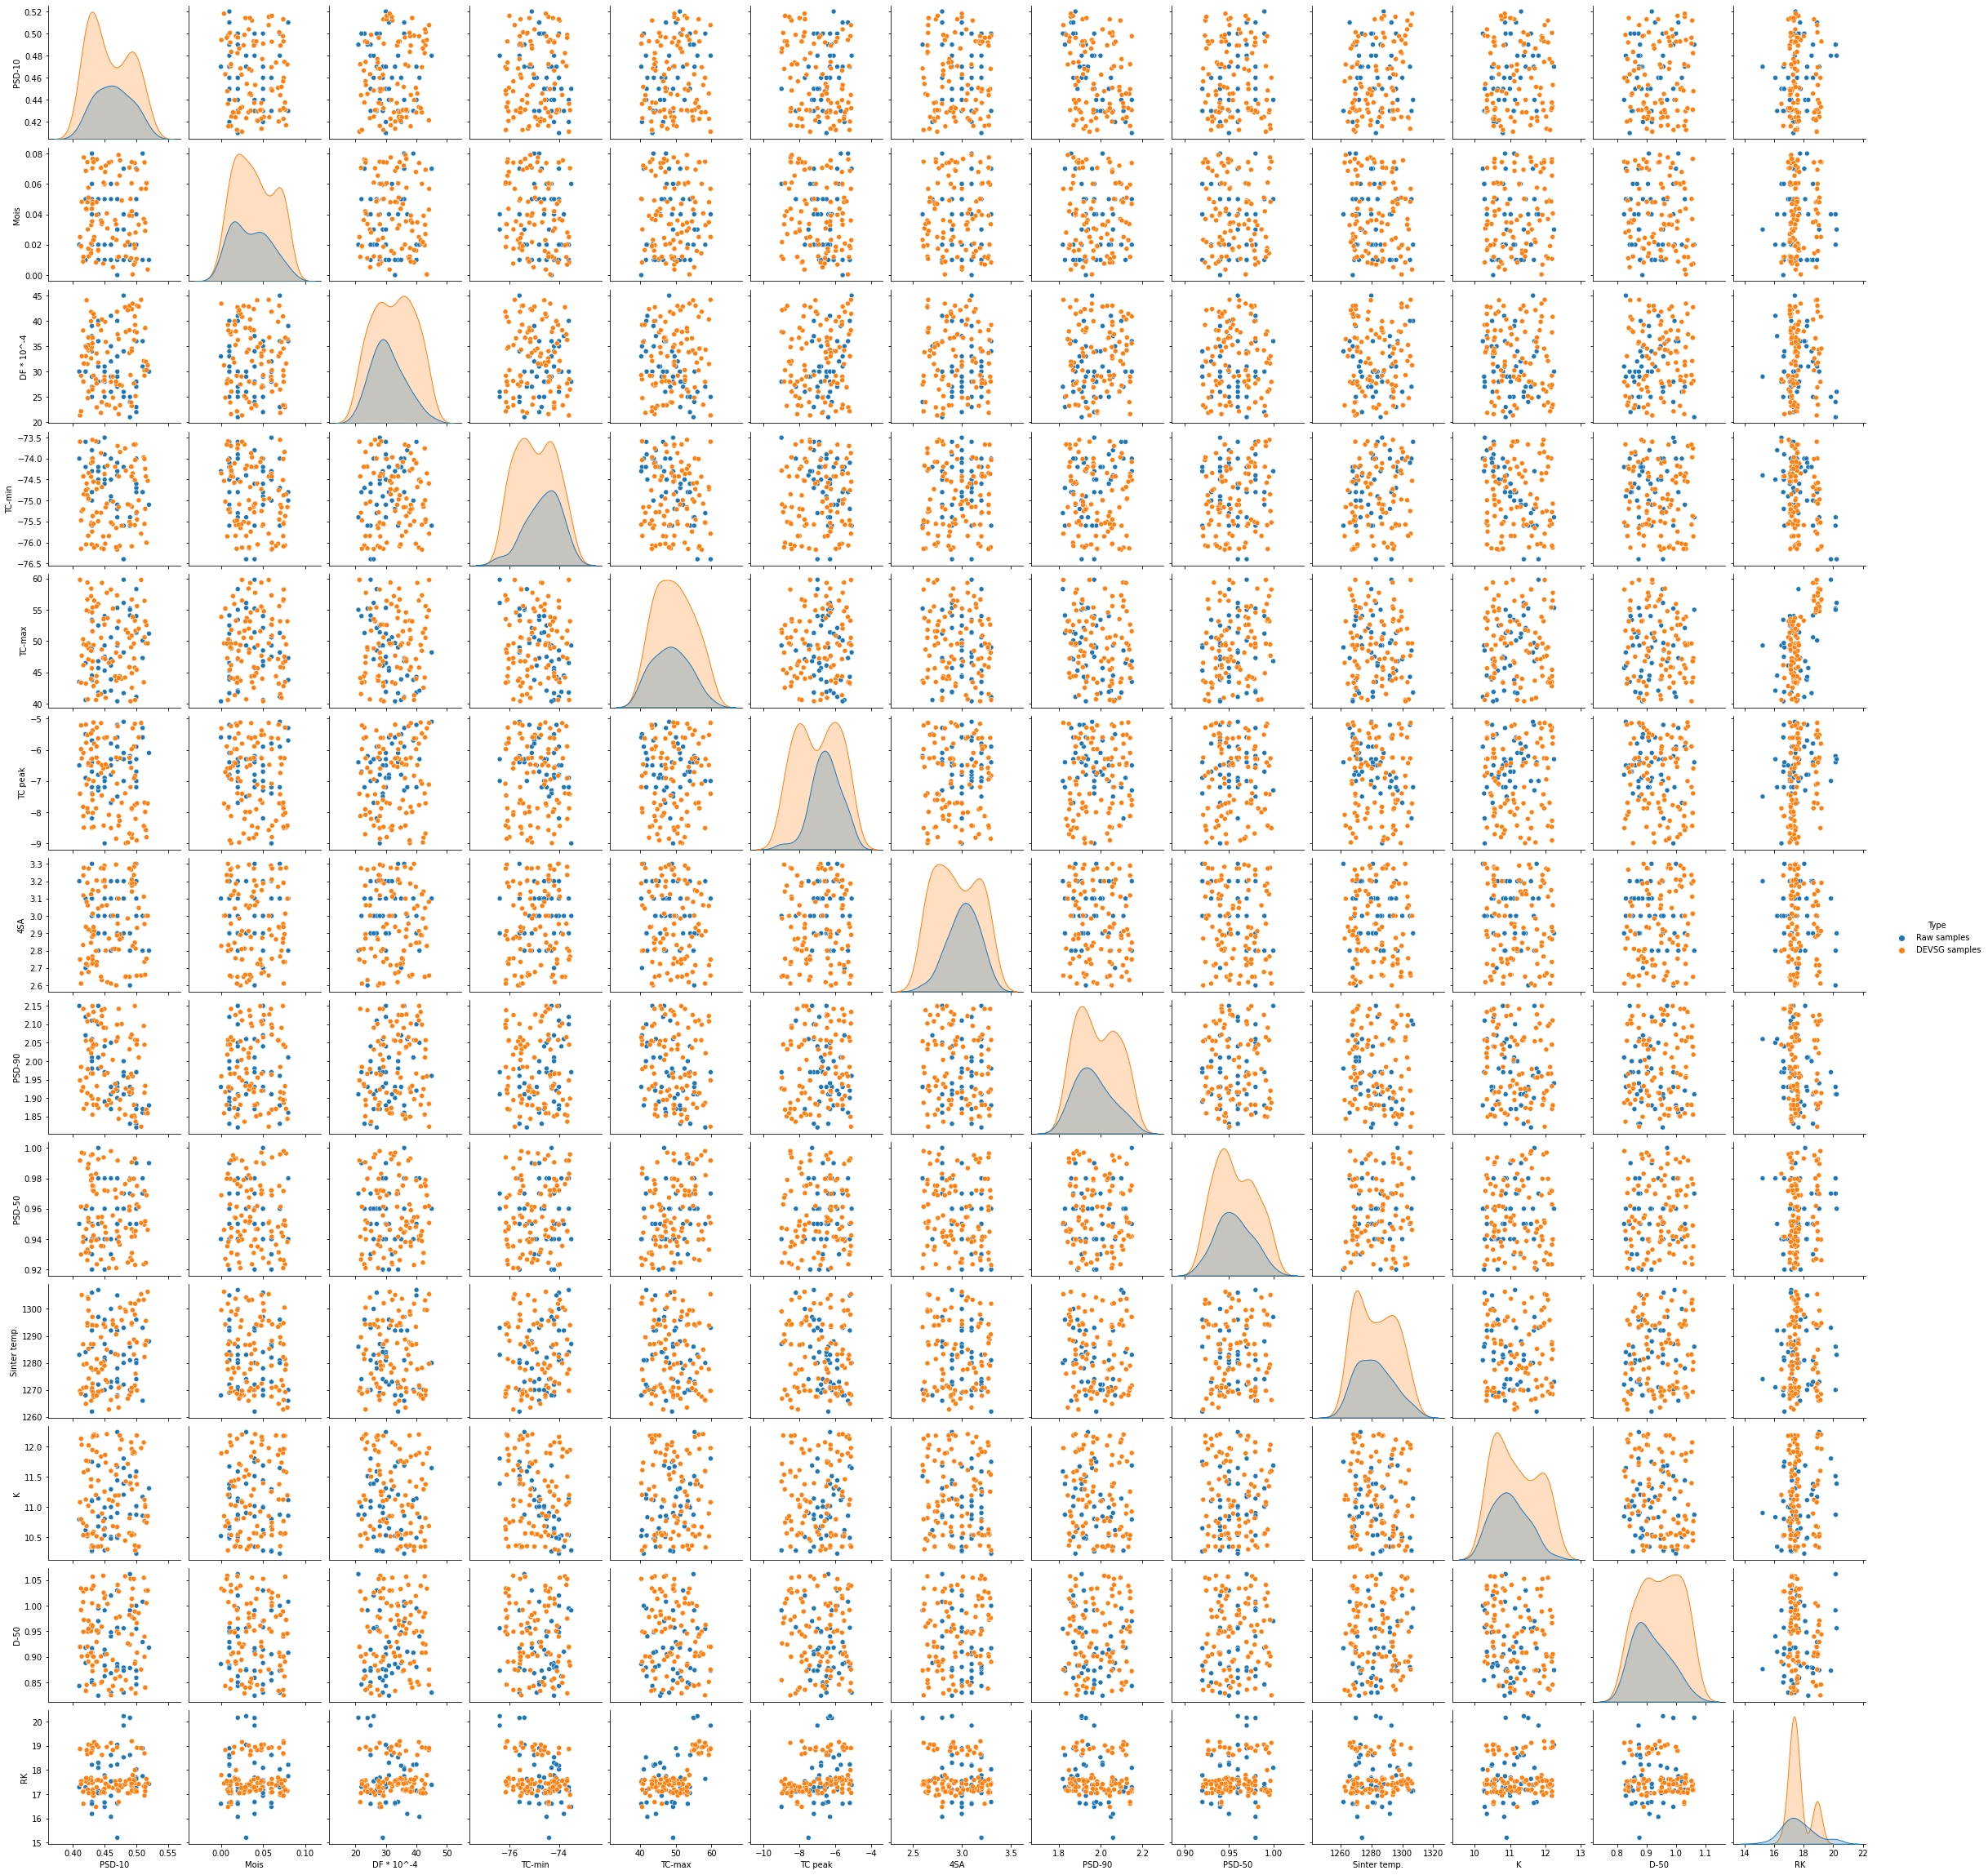

In [ ]:
sns.pairplot(data_new_train, hue='Type')

# PSO

UB :
PSD-10             0.557053
Mois               0.117882
DF * 10^-4        48.294444
TC-min           -72.087692
TC-max            70.437500
TC peak           -3.994902
4SA                3.519608
PSD-90             2.403846
PSD-50             1.019098
Sinter temp.    1329.906250
K                 13.341055
D-50               1.124688
dtype: float64
LB :
PSD-10             0.316667
Mois              -0.023231
DF * 10^-4         7.908333
TC-min           -77.948235
TC-max            32.170952
TC peak          -12.235385
4SA                2.476923
PSD-90             1.699216
PSD-50             0.872000
Sinter temp.    1245.883333
K                  9.296785
D-50               0.721595
dtype: float64


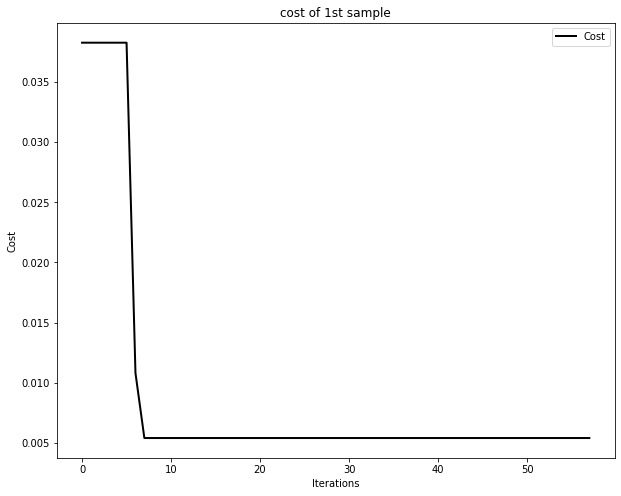

,PSD-10,Mois,DF * 10^-4,TC-min,TC-max,TC peak,4SA,PSD-90,PSD-50,Sinter temp.,K,D-50,RK
0,0.316667,0.117882,7.908333,-74.581579,67.872622,-12.235385,3.459041,2.403846,0.872000,1325.841153,10.501710,1.002251,0.368085
1,0.557053,0.091616,34.913176,-72.087692,70.437500,-6.302101,2.476923,1.699216,1.004006,1295.550994,13.324679,0.721595,0.680453
2,0.316667,0.117882,27.948548,-77.367641,32.170952,-11.803675,2.825586,2.281318,1.019098,1287.623287,9.296785,1.124688,0.344800
3,0.317815,0.010126,13.767551,-72.818583,33.359103,-7.800459,3.519608,1.790529,1.019098,1329.906250,9.296785,1.118686,0.418970
4,0.557053,0.117882,7.908333,-74.404906,70.437500,-11.199316,3.519608,1.969984,1.019098,1329.906250,13.291550,0.721595,0.484013
...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,0.557053,0.113232,39.679369,-74.127634,70.437500,-11.367415,2.632204,1.699216,1.019098,1245.883333,11.453956,0.941270,0.599920
96,0.454088,0.061942,18.007599,-77.648928,44.903677,-6.448374,3.472918,2.403846,0.875763,1282.322411,9.366662,0.881660,0.386538
97,0.316667,0.098431,15.790154,-75.067415,44.559455,-10.401305,2.543652,1.947124,0.949014,1309.940751,13.064817,0.830037,0.368065
98,0.557053,-0.023231,48.294444,-77.694321,52.054692,-9.163700,2.737689,1.699216,1.019098,1245.969279,13.341055,0.818074,0.592543


In [ ]:
RF.fit(data_train.loc(axis=1)[columns_x], data_train['RK'])
################## PSO
# Domain expansion
CL = np.mean(data_train.loc(axis=1)[columns_x])
N_L = np.count_nonzero(data_train.loc(axis=1)[columns_x] < CL, axis=0)
N_U = np.count_nonzero(data_train.loc(axis=1)[columns_x] > CL, axis=0)
s_p = 1
sk_L = N_L / (N_L + N_U + s_p)
sk_U = N_U / (N_L + N_U + s_p)
#print(f"sk_L :: {sk_L}")
LB = CL - 1/sk_U * (CL - np.min(data_train.loc(axis=1)[columns_x], axis=0))
UB = CL + 1/sk_L * (np.max(data_train.loc(axis=1)[columns_x], axis=0) - CL)
#print(f"sku :: {sk_U}")
#LB = np.maximum(LB, 0)
print(f"UB :\n{UB}")
print(f"LB :\n{LB}")
# This domain expansion is better
# m = data_train.shape[0]/10
# CL = data_train.loc(axis=1)[columns_x].median() #np.mean(data_train.loc(axis=1)[columns_x])
# N_L = np.count_nonzero(data_train.loc(axis=1)[columns_x] < CL, axis=0)
# N_U = np.count_nonzero(data_train.loc(axis=1)[columns_x] > CL, axis=0)
# print(f"N_L :: {N_L} | N_U :: {N_U}")
# LS = N_L / (N_L + N_U + m)
# RS = N_U / (N_L + N_U + m)
# S_x = np.sum((data_train.loc(axis=1)[columns_x] - CL)**2, axis=0) / (data_train.shape[0]-1)
# #print(S_x)
# LB = CL - LS * np.sqrt(-2*S_x/N_L * np.log(10**-20))
# UB = CL + RS * np.sqrt(-2*S_x/N_U * np.log(10**-20))
# #LB = np.maximum(LB, 0)
# LB = np.minimum(LB, np.min(data_train.loc(axis=1)[columns_x], axis=0))
# UB = np.maximum(UB, np.max(data_train.loc(axis=1)[columns_x], axis=0))

# PSO
def f(x):
  verbose = False
  #y = x[:, -1]
  y = data_train['RK']
  if verbose:
    print(f"x :: {x}")
  cost = np.zeros((x.shape[0]))
  c = 0
  for i in range(x.shape[0]):
    cost[i] = np.min(100 * np.abs((y - RF.predict(x[i, :].reshape(1, -1))) / y))

  return cost

bounds = np.array([[a,b,c,d,e,f,g,h,i,j,k,l] for (a,b,c,d,e,f,g,h,i,j,k,l) in itertools.product(UB.append(LB)['PSD-10'], UB.append(LB)['Mois'], UB.append(LB)['DF * 10^-4'], \
                   UB.append(LB)['TC-min'], UB.append(LB)['TC-max'], UB.append(LB)['TC peak'], UB.append(LB)['4SA'], UB.append(LB)['PSD-90'], \
                   UB.append(LB)['PSD-50'], UB.append(LB)['Sinter temp.'], UB.append(LB)['K'], UB.append(LB)['D-50'])])

optimizer = ps.single.GlobalBestPSO(n_particles=50, dimensions=columns_x.shape[0], options={'c1': 2, 'c2': 2, 'w': 0.9}, \
                                    #init_pos=bounds[np.random.choice(bounds.shape[0], size=50, replace=False)], \
                                    bounds=(np.array(LB), np.array(UB)), \
                                    ftol=10**-6, \
                                    ftol_iter=50, \
                                    bh_strategy='nearest', \
                                    oh_strategy={'w': "lin_variation"}, \
                                    )
cost, pos = optimizer.optimize(f, iters=500, n_processes=4, verbose=False)
plot_cost_history(optimizer.cost_history)
plt.title("cost of 1st sample")
plt.show()
# # Make animation
# animation = plot_contour(pos_history=optimizer.pos_history, \
#                          designer=Designer(limits=[(LB['Mois'], UB['Mois']), (LB['X2'], UB['X2'])], label=["Mois", "X2"]), \
#                          animator=Animator(repeat_delay=5000), \
#                          mark=pos, \
#                          )
# # Enables us to view it in a Jupyter notebook
# animation.save('plot0.gif', writer='imagemagick', fps=10)
# Image(url='plot0.gif')
#print(f"new sample :: {pos}")
data_new = pd.DataFrame(pos.reshape(1, -1), columns=columns_x)
data_new['RK'] = RF.predict(pos.reshape(1, -1))
data_new
for i in tqdm(range(1, number_new_samples)):
  optimizer = ps.single.GlobalBestPSO(n_particles=50, dimensions=columns_x.shape[0], options={'c1': 2, 'c2': 2, 'w': 0.9}, \
                                    #init_pos=bounds[np.random.choice(bounds.shape[0], size=50, replace=False)], \
                                    bounds=(np.array(LB), np.array(UB)), \
                                    ftol=10**-6, \
                                    ftol_iter=50, \
                                    bh_strategy='nearest', \
                                    oh_strategy={'w': "lin_variation"}, \
                                    )# https://github.com/ljvmiranda921/pyswarms/blob/master/docs/examples/tutorials/options_handler.ipynb
  cost, pos = optimizer.optimize(f, iters=500, n_processes=4, verbose=False)
  nd = pd.DataFrame(pos.reshape(1, -1), columns=columns_x)
  nd['RK'] = RF.predict(pos.reshape(1, -1))
  data_new = data_new.append(nd, ignore_index=True)

data_new

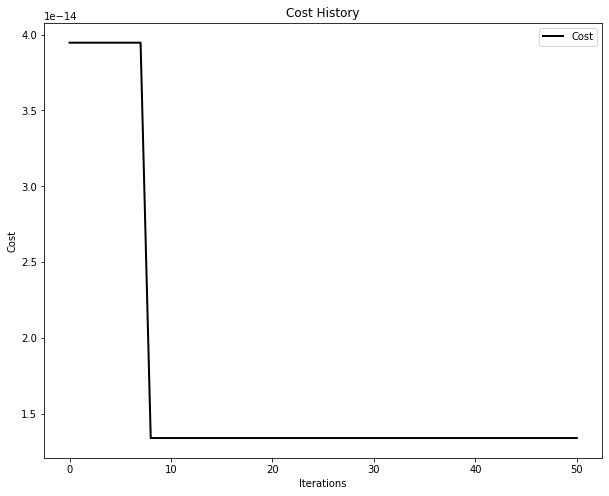

2021-04-07 08:13:31,318 - matplotlib.animation - INFO - Animation.save using <class 'matplotlib.animation.ImageMagickWriter'>
2021-04-07 08:13:31,322 - matplotlib.animation - INFO - MovieWriter._run: running command: convert -size 720x576 -depth 8 -delay 100.0 -loop 0 rgba:- plot1.gif


PSD-10             0.351628
Mois               0.032778
DF * 10^-4        14.296257
TC-min           -73.852919
TC-max            64.876841
TC peak           -6.963238
4SA                2.668711
PSD-90             2.340242
PSD-50             0.872000
Sinter temp.    1321.034037
K                 12.292390
D-50               1.124688
RK                 0.414794
Name: 99, dtype: float64


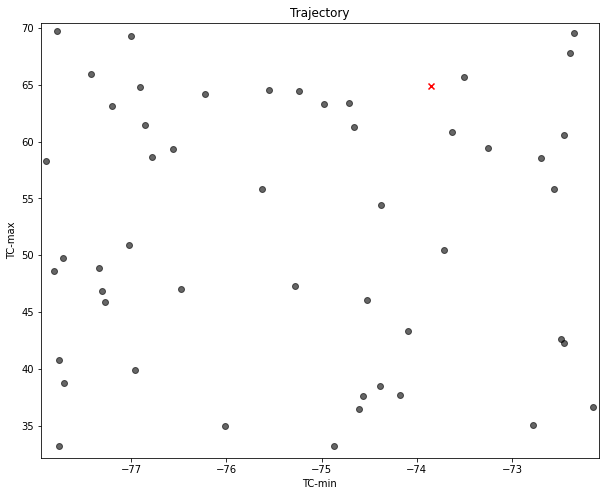

In [ ]:
plot_cost_history(optimizer.cost_history)
plt.show()
print(data_new.iloc[-1])
# Make animation
animation = plot_contour(pos_history=np.array(optimizer.pos_history)[:,:,3:5], \
                         designer=Designer(limits=[(LB['TC-min'], UB['TC-min']), (LB['TC-max'], UB['TC-max'])], label=["TC-min", "TC-max"]), \
                         animator=Animator(repeat_delay=5000), \
                         mark=data_new.iloc[-1].loc[['TC-min', 'TC-max']], \
                         )
# Enables us to view it in a Jupyter notebook
animation.save('plot1.gif', writer='imagemagick', fps=1)
Image(url='plot1.gif')

In [ ]:
data_new_train = data_train.append(data_new)
data_new_train['Type'] = np.concatenate((np.full((data_train.shape[0]), "Raw samples"), np.full((data_new.shape[0]), "PSOVSG samples")), axis=0)
#TODO

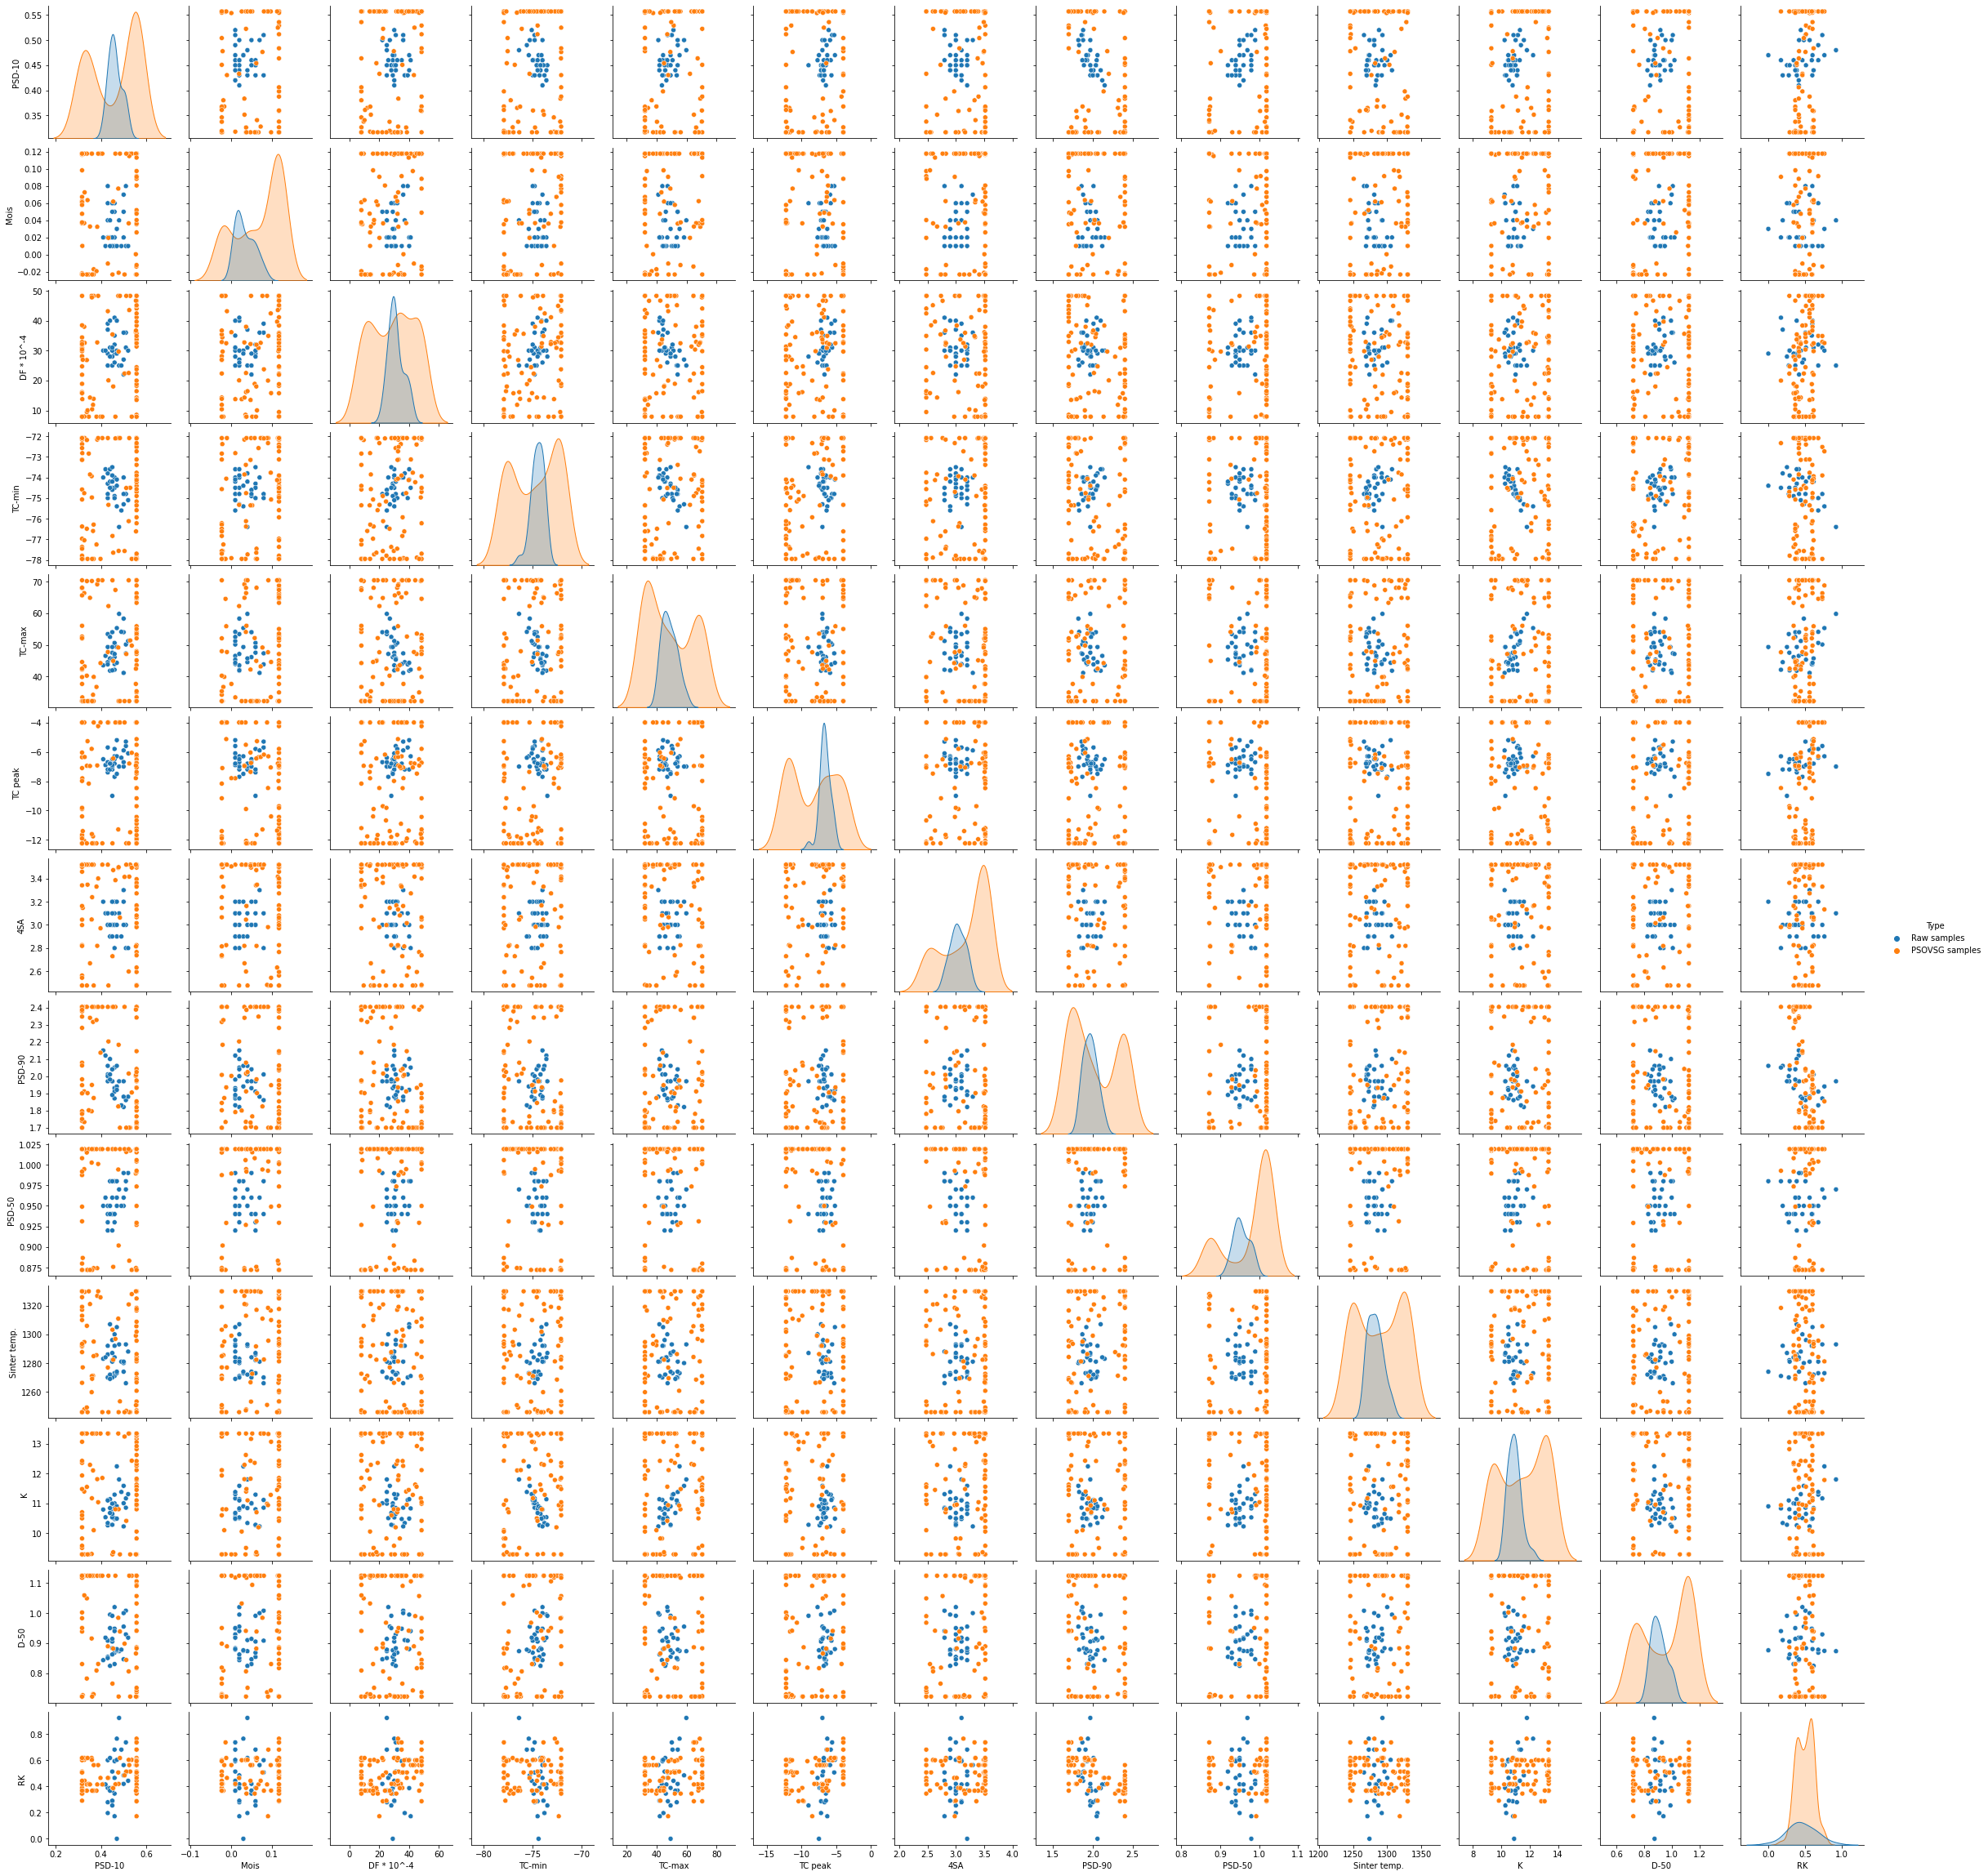

In [ ]:
sns.pairplot(data_new_train, hue='Type')

# Middle Points

In [ ]:
RF.fit(data_train.loc(axis=1)[columns_x], data_train["RK"])
data_new = data_train.copy()
for i in tqdm(range(number_new_samples)):
  index = np.random.choice(data_new.index, size=3, replace=False)
  nd = data_new.loc[index, columns_x].mean()
  nd = pd.DataFrame(np.array(nd).reshape(1, -1), columns=columns_x)
  nd['RK'] = RF.predict(nd)
  data_new = data_new.append(nd, ignore_index=True)

2021-03-23 15:50:09,705 - numexpr.utils - INFO - NumExpr defaulting to 2 threads.


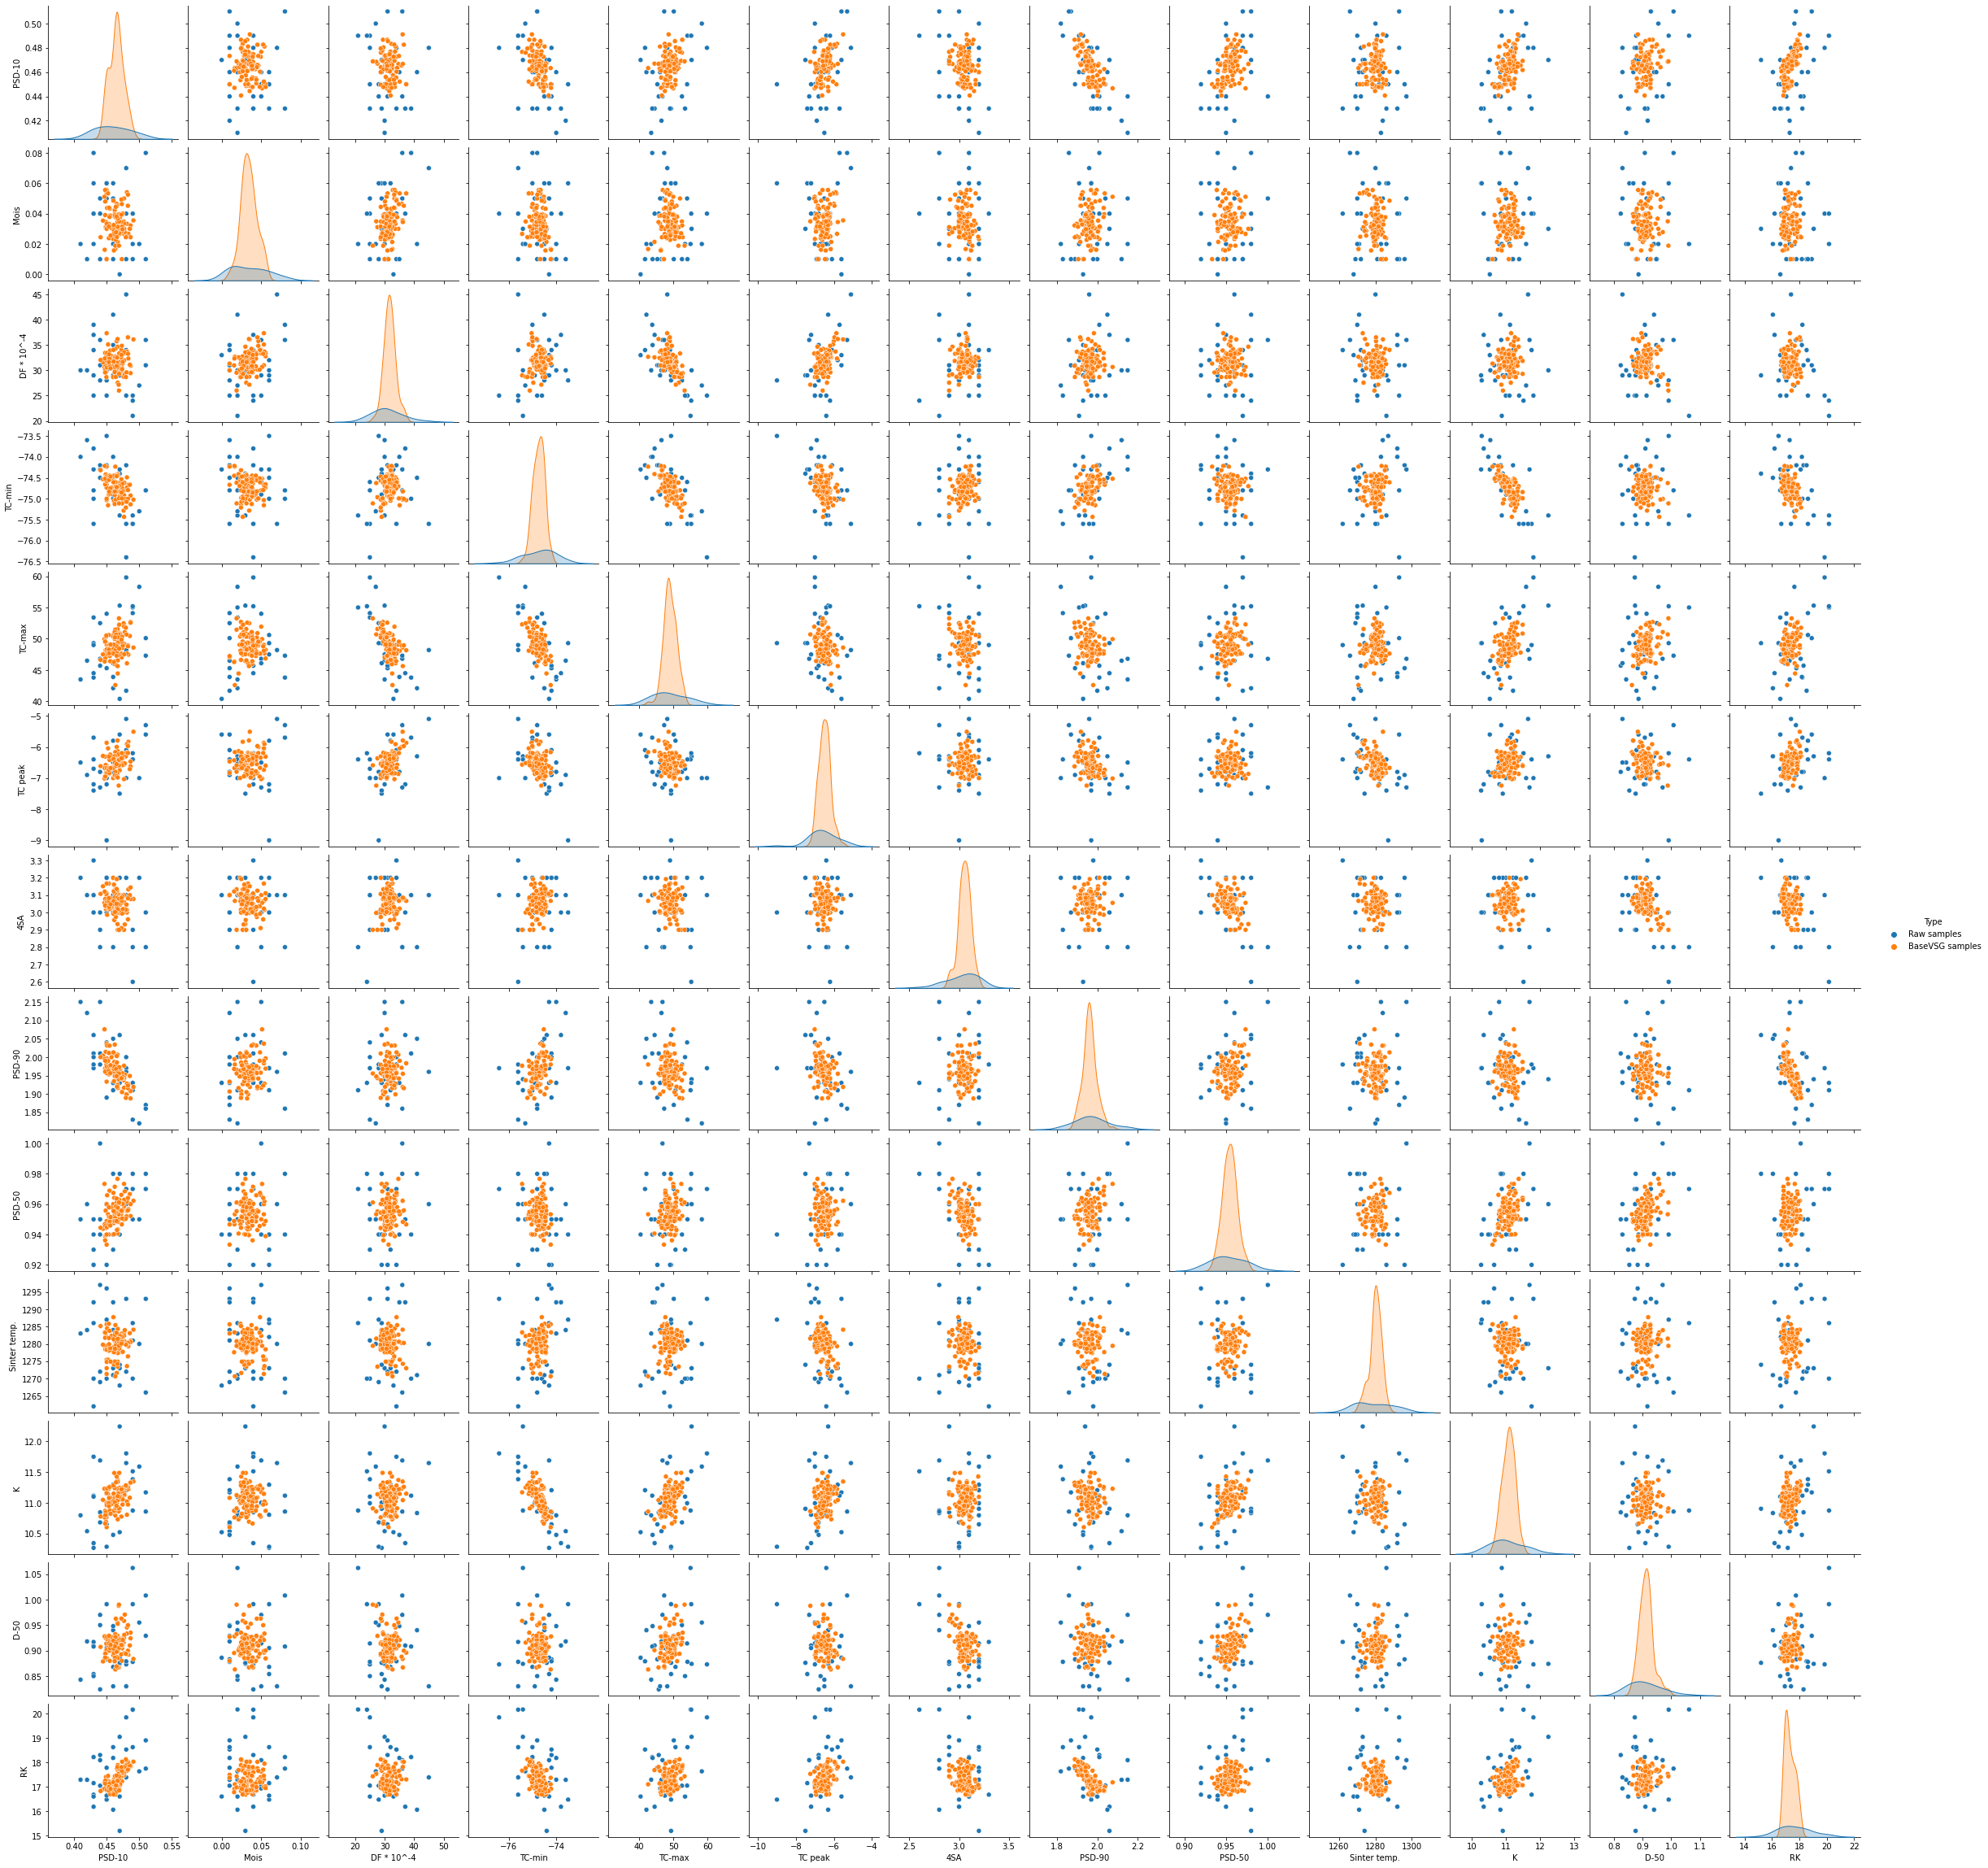

In [ ]:
data_new_train = data_new
data_new_train['Type'] = np.concatenate((np.full((data_train.shape[0]), "Raw samples"), np.full((number_new_samples), "BaseVSG samples")), axis=0)
sns.pairplot(data_new_train, hue='Type')

# Prediction

In [ ]:
data_train_vsg = data_train.append(data_new)
RF.fit(data_train_vsg.loc(axis=1)[columns_x], data_train_vsg["RK"])
test_prediction_vsg = RF.predict(data_test.loc(axis=1)[columns_x])
print(f"{np.array(data_test.loc(axis=1)[columns_y])} || {test_prediction_vsg}")
print(f"MSE :: {mean_squared_error(data_test.loc(axis=1)[columns_y], test_prediction_vsg)}")
print(f"RMSE :: {np.sqrt(mean_squared_error(data_test.loc(axis=1)[columns_y], test_prediction_vsg))}")
print(f"MAPE :: {mean_absolute_percentage_error(data_test.loc(axis=1)[columns_y], test_prediction_vsg)}")

[[0.49433287]
 [0.43487771]
 [1.        ]
 [0.98687612]
 [0.37999602]
 [0.98528534]
 [0.2793796 ]
 [0.47245973]
 [0.2942931 ]
 [0.28614039]
 [0.41459535]
 [0.39490952]
 [0.57486578]
 [0.66136409]] || [0.49773315 0.6668105  0.73048519 0.59390336 0.31541857 0.66699145
 0.61630543 0.32507457 0.62461722 0.66281567 0.4172579  0.57411016
 0.39254325 0.60727779]
MSE :: 0.060062710058046066
RMSE :: 0.24507694721871753
MAPE :: 0.46548642547156366


# AveMAPE

In [ ]:
ave_mape_raw = []
ave_mape_psovsg = []
ave_mape_basevsg = []
ave_mape_devsg = []
ave_rmse_raw = []
ave_rmse_psovsg = []
ave_rmse_basevsg = []
ave_rmse_devsg = []
mape_raw = []
mape_psovsg = []
mape_basevsg = []
mape_devsg = []
rmse_raw = []
rmse_psovsg = []
rmse_basevsg = []
rmse_devsg = []
nbr_y_zero = []
PSO = True
base = True
DE = True
normalize = False
n_runs = 15
train_sizes = [25, 30]#[5, 10, 15, 20, 25, 30]
for train_size in train_sizes:
  print(f"train size :: {train_size}")
  offset = (train_size // 5) - 1
  avemape_raw = 0
  avemape_psovsg = 0
  avemape_basevsg = 0
  avemape_devsg = 0
  avermse_raw = 0
  avermse_psovsg = 0
  avermse_basevsg = 0
  avermse_devsg = 0
  mape_raw.append([])
  mape_psovsg.append([])
  mape_basevsg.append([])
  mape_devsg.append([])
  rmse_raw.append([])
  rmse_psovsg.append([])
  rmse_basevsg.append([])
  rmse_devsg.append([])
  nbr_y_zero.append([])
  for run in tqdm(range(n_runs)):
    data = pd.read_csv("/content/drive/MyDrive/pso_data.csv", decimal=',', index_col=0)
    columns_x = data.columns[data.columns != 'RK']
    columns_y = data.columns[data.columns == 'RK']
    data = data.apply(pd.to_numeric)
    data['TC-min'] = - data['TC-min']
    data['TC peak'] = - data['TC peak']
    data_train, data_test = train_test_split(data, train_size=train_size, random_state=run)
    if normalize:
      data_test = data_test.copy()
      data_train = data_train.copy()
      data_test.loc[:, columns_y] = data_test["RK"].apply(lambda x: (x - data["RK"].min())/(data["RK"].max() - data["RK"].min()))
      data_train.loc[:, columns_y] = data_train["RK"].apply(lambda x: (x - data["RK"].min())/(data["RK"].max() - data["RK"].min()))
      nbr_y_zero[offset].append(np.count_nonzero(np.isclose(data_test.loc[:, columns_y], np.zeros(data_test.shape))))
    ###################################################################################################
    number_new_samples = 100
    desired_fitness = 10**-6
    RF = RandomForestRegressor(n_estimators=10)
    RF = KNeighborsRegressor()
    RF.fit(data_train.loc(axis=1)[columns_x], data_train['RK'])
    test_prediction = RF.predict(data_test.loc(axis=1)[columns_x])
    avermse_raw += np.sqrt(mean_squared_error(data_test.loc(axis=1)[columns_y], test_prediction))
    avemape_raw += mean_absolute_percentage_error(data_test.loc(axis=1)[columns_y], test_prediction)
    mape_raw[offset].append(mean_absolute_percentage_error(data_test.loc(axis=1)[columns_y], test_prediction))
    rmse_raw[offset].append(np.sqrt(mean_squared_error(data_test.loc(axis=1)[columns_y], test_prediction)))
    ####################################################################################################
    RF.fit(data_train.loc(axis=1)[columns_x], data_train['RK'])
    if PSO:
      ################## PSO
      # Domain expansion
      CL = np.mean(data_train.loc(axis=1)[columns_x])
      N_L = np.count_nonzero(data_train.loc(axis=1)[columns_x] < CL, axis=0)
      N_U = np.count_nonzero(data_train.loc(axis=1)[columns_x] > CL, axis=0)
      s_p = 1
      sk_L = N_L / (N_L + N_U + s_p)
      sk_U = N_U / (N_L + N_U + s_p)
      #print(f"sk_L :: {sk_L}")
      LB = CL - 1/sk_U * (CL - np.min(data_train.loc(axis=1)[columns_x], axis=0))
      UB = CL + 1/sk_L * (np.max(data_train.loc(axis=1)[columns_x], axis=0) - CL)
      #print(f"sku :: {sk_U}")
      #LB = np.maximum(LB, 0)
      # This domain expansion is better
      # m = data_train.shape[0]/10
      # CL = data_train.loc(axis=1)[columns_x].median() #np.mean(data_train.loc(axis=1)[columns_x])
      # N_L = np.count_nonzero(data_train.loc(axis=1)[columns_x] < CL, axis=0)
      # N_U = np.count_nonzero(data_train.loc(axis=1)[columns_x] > CL, axis=0)
      # print(f"N_L :: {N_L} | N_U :: {N_U}")
      # LS = N_L / (N_L + N_U + m)
      # RS = N_U / (N_L + N_U + m)
      # S_x = np.sum((data_train.loc(axis=1)[columns_x] - CL)**2, axis=0) / (data_train.shape[0]-1)
      # #print(S_x)
      # LB = CL - LS * np.sqrt(-2*S_x/N_L * np.log(10**-20))
      # UB = CL + RS * np.sqrt(-2*S_x/N_U * np.log(10**-20))
      # #LB = np.maximum(LB, 0)
      # LB = np.minimum(LB, np.min(data_train.loc(axis=1)[columns_x], axis=0))
      # UB = np.maximum(UB, np.max(data_train.loc(axis=1)[columns_x], axis=0))

      # PSO
      def f(x):
        verbose = False
        #y = x[:, -1]
        y = data_train['RK']
        if verbose:
          print(f"x :: {x}")
        cost = np.zeros((x.shape[0]))
        c = 0
        for i in range(x.shape[0]):
          cost[i] = np.min(100 * np.abs((y - RF.predict(x[i, :].reshape(1, -1)))))
          # if cost[i] > 0.1:
          #   cost[i] = np.inf

        return cost

      bounds = np.array([[a,b,c,d,e,f,g,h,i,j,k,l] for (a,b,c,d,e,f,g,h,i,j,k,l) in itertools.product(UB.append(LB)['PSD-10'], UB.append(LB)['Mois'], UB.append(LB)['DF * 10^-4'], \
                        UB.append(LB)['TC-min'], UB.append(LB)['TC-max'], UB.append(LB)['TC peak'], UB.append(LB)['4SA'], UB.append(LB)['PSD-90'], \
                        UB.append(LB)['PSD-50'], UB.append(LB)['Sinter temp.'], UB.append(LB)['K'], UB.append(LB)['D-50'])])

      optimizer = ps.single.GlobalBestPSO(n_particles=50, dimensions=columns_x.shape[0], options={'c1': 2, 'c2': 2, 'w': 0.9}, \
                                          #init_pos=bounds[np.random.choice(bounds.shape[0], size=50, replace=False)], \
                                          bounds=(np.array(LB), np.array(UB)), \
                                          ftol=10**-6, \
                                          ftol_iter=50, \
                                          bh_strategy='nearest', \
                                          oh_strategy={'w': "lin_variation"}, \
                                          )
      cost, pos = optimizer.optimize(f, iters=500, n_processes=4, verbose=False)
      data_new = pd.DataFrame(pos.reshape(1, -1), columns=columns_x)
      data_new['RK'] = RF.predict(pos.reshape(1, -1))
      data_new
      for i in range(1, number_new_samples):
        optimizer = ps.single.GlobalBestPSO(n_particles=50, dimensions=columns_x.shape[0], options={'c1': 2, 'c2': 2, 'w': 0.9}, \
                                          #init_pos=bounds[np.random.choice(bounds.shape[0], size=50, replace=False)], \
                                          bounds=(np.array(LB), np.array(UB)), \
                                          ftol=10**-6, \
                                          ftol_iter=50, \
                                          bh_strategy='nearest', \
                                          oh_strategy={'w': "lin_variation"}, \
                                          )# https://github.com/ljvmiranda921/pyswarms/blob/master/docs/examples/tutorials/options_handler.ipynb
        cost, pos = optimizer.optimize(f, iters=500, n_processes=4, verbose=False)
        nd = pd.DataFrame(pos.reshape(1, -1), columns=columns_x)
        nd['RK'] = RF.predict(pos.reshape(1, -1))
        data_new = data_new.append(nd, ignore_index=True)
      ################################################################################################################################################
      data_train_vsg = data_train.append(data_new)
      RF.fit(data_train_vsg.loc(axis=1)[columns_x], data_train_vsg["RK"])
      test_prediction_psovsg = RF.predict(data_test.loc(axis=1)[columns_x])
      avermse_psovsg += np.sqrt(mean_squared_error(data_test.loc(axis=1)[columns_y], test_prediction_psovsg))
      avemape_psovsg += mean_absolute_percentage_error(data_test.loc(axis=1)[columns_y], test_prediction_psovsg)
      mape_psovsg[offset].append(mean_absolute_percentage_error(data_test.loc(axis=1)[columns_y], test_prediction_psovsg))
      rmse_psovsg[offset].append(np.sqrt(mean_squared_error(data_test.loc(axis=1)[columns_y], test_prediction_psovsg)))
    ################################################################################################################################################
    if base:
      RF.fit(data_train.loc(axis=1)[columns_x], data_train["RK"])
      data_new = data_train.copy()
      for i in range(number_new_samples):
        index = np.random.choice(data_new.index, size=3, replace=False)
        nd = data_new.loc[index, columns_x].mean()
        nd = pd.DataFrame(np.array(nd).reshape(1, -1), columns=columns_x)
        nd['RK'] = RF.predict(nd)
        data_new = data_new.append(nd, ignore_index=True)


      ################################################################################################################################################
      data_train_vsg = data_new
      RF.fit(data_train_vsg.loc(axis=1)[columns_x], data_train_vsg["RK"])
      test_prediction_basevsg = RF.predict(data_test.loc(axis=1)[columns_x])
      avermse_basevsg += np.sqrt(mean_squared_error(data_test.loc(axis=1)[columns_y], test_prediction_basevsg))
      avemape_basevsg += mean_absolute_percentage_error(data_test.loc(axis=1)[columns_y], test_prediction_basevsg)
      mape_basevsg[offset].append(mean_absolute_percentage_error(data_test.loc(axis=1)[columns_y], test_prediction_basevsg))
      rmse_basevsg[offset].append(np.sqrt(mean_squared_error(data_test.loc(axis=1)[columns_y], test_prediction_basevsg)))
    ####################################################################################################################################################
    if DE:
      RF.fit(data_train.loc(axis=1)[columns_x], data_train['RK'])
      ########### DE
      m = data_train.shape[0]/10
      CL = data_train.loc(axis=1)[columns_x].median() #np.mean(data_train.loc(axis=1)[columns_x])
      N_L = np.count_nonzero(data_train.loc(axis=1)[columns_x] < CL, axis=0)
      N_L = np.maximum(N_L, [0.1]*columns_x.shape[0])
      N_U = np.count_nonzero(data_train.loc(axis=1)[columns_x] > CL, axis=0)
      N_U = np.maximum(N_U, [0.1]*columns_x.shape[0])
      LS = N_L / (N_L + N_U + m)
      RS = N_U / (N_L + N_U + m)
      S_x = np.sum((data_train.loc(axis=1)[columns_x] - CL)**2, axis=0) / (data_train.shape[0]-1)
      LB = CL - LS * np.sqrt(-2*S_x/N_L * np.log(10**-20))
      UB = CL + RS * np.sqrt(-2*S_x/N_U * np.log(10**-20))
      LB = np.minimum(LB, np.min(data_train.loc(axis=1)[columns_x], axis=0))
      UB = np.maximum(UB, np.max(data_train.loc(axis=1)[columns_x], axis=0))
      # DE
      def f(x):
        if not LB.equals(np.minimum(LB, x)):
          return np.inf
        if not UB.equals(np.maximum(UB, x)):
          return np.inf
        y = data_train['RK']
        return np.min(100* np.abs((y - RF.predict(np.array(x).reshape(1, -1)))))

      M = number_new_samples # number of data to produce
      data_new = pd.DataFrame(columns=columns_x)
      for i in range(M):
        new_x = []
        for attr in columns_x:
          new_x.append(LB[attr] + np.random.uniform() * (UB[attr] - LB[attr]))
        new_data = pd.DataFrame(np.array(new_x).reshape(1, -1), columns=columns_x)
        data_new = data_new.append(new_data, ignore_index=True)
      count = 0
      for g in range(50): # iterations
        fitness = 0
        for i in range(data_new.shape[0]):
          # Mutation
          F = 1.2#0.6 # scaling factor between [0,2]
          parents = data_new.loc[np.random.randint(0, data_new.shape[0], 3), :]
          p1 = parents.iloc[0]
          p2 = parents.iloc[1]
          p3 = parents.iloc[2]
          h = p1 + F * (p2 - p3)
          # Crossover
          P_cr = 0.7 # probability of crossover
          v_x = []
          for attr in columns_x:
            v_x.append(h[attr] if np.random.uniform() <= P_cr else data_new.loc[i, attr])
          v = pd.DataFrame(np.array(v_x).reshape(1, -1), columns=columns_x)
          # Selection
          if f(v.loc[0, :]) < f(data_new.loc[i, :]):
            for attr in columns_x:
              data_new.at[i, attr] = v[attr]
          fitness += f(data_new.loc[i, :])
        if fitness < 10**-3:
          break

      data_new['RK'] = RF.predict(np.array(data_new[columns_x]))
      ################################################################################################################################################
      data_train_vsg = data_new
      RF.fit(data_train_vsg.loc(axis=1)[columns_x], data_train_vsg["RK"])
      test_prediction_devsg = RF.predict(data_test.loc(axis=1)[columns_x])
      avermse_devsg += np.sqrt(mean_squared_error(data_test.loc(axis=1)[columns_y], test_prediction_devsg))
      avemape_devsg += mean_absolute_percentage_error(data_test.loc(axis=1)[columns_y], test_prediction_devsg)
      mape_devsg[offset].append(mean_absolute_percentage_error(data_test.loc(axis=1)[columns_y], test_prediction_devsg))
      rmse_devsg[offset].append(np.sqrt(mean_squared_error(data_test.loc(axis=1)[columns_y], test_prediction_devsg)))

  ave_mape_raw.append(avemape_raw / n_runs)
  ave_mape_psovsg.append(avemape_psovsg / n_runs)
  ave_mape_basevsg.append(avemape_basevsg / n_runs)
  ave_mape_devsg.append(avemape_devsg / n_runs)
  ave_rmse_raw.append(avermse_raw / n_runs)
  ave_rmse_psovsg.append(avermse_psovsg / n_runs)
  ave_rmse_basevsg.append(avermse_basevsg / n_runs)
  ave_rmse_devsg.append(avermse_devsg / n_runs)

train size :: 25



train size :: 30


In [ ]:
print(f"ave_mape_raw = {ave_mape_raw}")
print(f"ave_mape_psovsg = {ave_mape_psovsg}")
print(f"ave_mape_basevsg = {ave_mape_basevsg}")
print(f"ave_mape_devsg = {ave_mape_devsg}")
print(f"ave_rmse_raw = {ave_rmse_raw}")
print(f"ave_rmse_psovsg = {ave_rmse_psovsg}")
print(f"ave_rmse_basevsg = {ave_rmse_basevsg}")
print(f"ave_rmse_devsg = {ave_rmse_devsg}")
print(f"mape_raw = {mape_raw}")
print(f"mape_psovsg = {mape_psovsg}")
print(f"mape_basevsg = {mape_basevsg}")
print(f"mape_devsg = {mape_devsg}")
print(f"rmse_raw = {rmse_raw}")
print(f"rmse_psovsg = {rmse_psovsg}")
print(f"rmse_basevsg = {rmse_basevsg}")
print(f"rmse_devsg = {rmse_devsg}")
print(f"nbr_y_zero = {nbr_y_zero}")

ave_mape_raw = [0.05589848144166814, 0.05471881610146054, 0.052100895895879094, 0.04977705711834957, 0.04881759864641714, 0.05206677529883453]
ave_mape_psovsg = [0.05621521151053157, 0.05415252339366103, 0.05091767744855405, 0.04941875334053989, 0.04903607776568666, 0.05229790716982919]
ave_mape_basevsg = [0.05576463308922619, 0.05375756007429254, 0.05123699251070237, 0.049828356702321025, 0.04928185508362532, 0.05285916079147386]
ave_mape_devsg = [0.05589848144166814, 0.05333078525950121, 0.05156247792077824, 0.0508148007560965, 0.04911783632131943, 0.0525524684203634]
ave_rmse_raw = [1.289451221317378, 1.2297843600036122, 1.177173472032519, 1.1214574246616207, 1.0877828817717436, 1.135707353397693]
ave_rmse_psovsg = [1.2934659057531392, 1.229078346055249, 1.1576865931147695, 1.113287946526232, 1.1027294223626294, 1.1538734231789116]
ave_rmse_basevsg = [1.284750625996762, 1.221650704672124, 1.1925749943810593, 1.1360616749001358, 1.126742609418369, 1.1762465940838889]
ave_rmse_devsg =

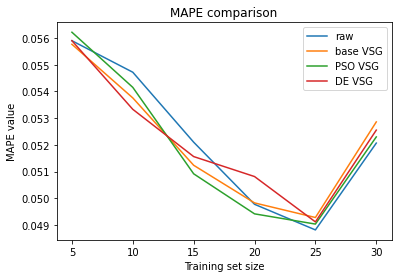

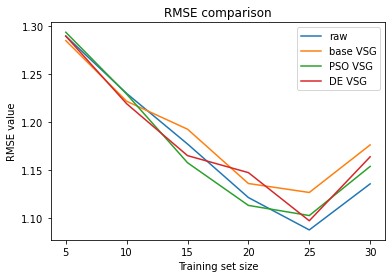

In [ ]:
train_sizes = [5, 10, 15, 20, 25, 30]
plt.plot(train_sizes, ave_mape_raw[:6], label="raw")
if base: plt.plot(train_sizes, ave_mape_basevsg[:6], label="base VSG")
if PSO: plt.plot(train_sizes, ave_mape_psovsg[:6], label="PSO VSG")
if DE: plt.plot(train_sizes, ave_mape_devsg[:6], label="DE VSG")
plt.xlabel("Training set size")
plt.ylabel("MAPE value")
plt.legend()
plt.title("MAPE comparison")
plt.savefig(f"{normalize}_mape_psodata_knn_mae.pdf")
plt.show()
plt.plot(train_sizes, ave_rmse_raw[:6], label="raw")
if base: plt.plot(train_sizes, ave_rmse_basevsg[:6], label="base VSG")
if PSO: plt.plot(train_sizes, ave_rmse_psovsg[:6], label="PSO VSG")
if DE: plt.plot(train_sizes, ave_rmse_devsg[:6], label="DE VSG")
plt.xlabel("Training set size")
plt.ylabel("RMSE value")
plt.legend()
plt.title("RMSE comparison")
plt.savefig(f"{normalize}_rmse_psodata_knn_mae.pdf")
plt.show()

In [ ]:
ave_mape_raw = [48634709101357.63, 44865846357379.96, 33439347923351.5, 34072271986972.453, 36756781000760.625, 45482479888724.64]
ave_mape_psovsg = [48510468280764.11, 48140644009058.92, 36572329758325.89, 37571091582147.75, 39283326581919.586, 51050134832423.766]
ave_mape_basevsg = [45437957272614.266, 41938266914722.47, 34665909570619.105, 34758145304651.348, 38879711498780.22, 54168014777840.984]
ave_mape_devsg = [49018024792296.71, 47255443020225.53, 37331385725032.88, 36216832577078.914, 39475251916899.34, 55064095026398.7]
ave_rmse_raw = [0.2635816710967656, 0.22949773012572436, 0.22462693801603448, 0.21223014235034712, 0.2079637415763943, 0.21260482925986335]
ave_rmse_psovsg = [0.2589958820729695, 0.2272082580544406, 0.23284812086593393, 0.21761949795751176, 0.22324044593390502, 0.22041193710554421]
ave_rmse_basevsg = [0.2643863175711375, 0.22623578118431695, 0.22122788010789302, 0.2091489237714602, 0.2128015531516782, 0.21988966353781939]
ave_rmse_devsg = [0.2647619060012822, 0.23298710044801485, 0.21411112541587982, 0.20523404276227047, 0.2037920115859593, 0.20616524406617456]
mape_raw = [[44514524667801.15, 78810869475305.52, 47141400568965.086, 42835987706480.51, 36884184965381.8, 82941769603097.53, 63398639537707.18, 44048391968556.125, 50075969976034.6, 42764804880487.445, 47763676241356.21, 46477792933094.17, 45368718579718.16, 56493905416378.57, 0.35533115590537556], [45155575317067.09, 50973859607512.88, 0.3320086902052991, 57832534253198.84, 73804501630864.12, 86573647054169.3, 51987910966418.04, 55303990605019.69, 58836050013569.98, 52188087338565.484, 54042352680563.59, 0.3875452977462346, 49148567161483.414, 37140618732265.89, 0.3717943041378233], [60219483090045.0, 0.4039204205215023, 0.42230866444371457, 0.3847950300576499, 77765614207302.34, 0.5319118527315019, 39443282780839.305, 0.35868041537196454, 56967797756276.66, 62751659703236.016, 72358490732061.72, 0.4379904253636424, 73392977519157.89, 58690913061350.57, 0.48503492187198244], [0.3686920710690365, 0.389411233210117, 0.3933128192789022, 0.3982421144449053, 88616016728327.61, 0.46524259390893175, 67365933976724.49, 0.40373981835494144, 66858469313999.66, 83254055549389.39, 80115983627686.42, 0.43325742082914825, 61615911585114.16, 63257709023341.78, 0.4184062371096744], [0.37148500548585656, 0.47502472187184214, 0.43726897014289784, 0.3345995725317541, 135101861538809.92, 0.4950029011210759, 69879298045436.79, 0.41440734154788106, 0.3303868418049118, 88402543783907.45, 76685294698452.44, 0.44667730022352237, 93917097858719.23, 87365619086079.7, 0.49147692425821393], [0.41565052858229834, 0.5864475969222395, 0.32309725520598154, 0.30429908849571835, 132742521187388.47, 0.6662049794920828, 112503636403421.03, 0.3082296654929014, 0.37436421316610397, 117518581305643.0, 99934291080887.42, 0.4632037453208152, 124580442494486.27, 94957725859039.45, 0.4866492131101508]]
mape_psovsg = [[53673228530897.74, 71253779197053.16, 47436924107846.06, 43881227138482.12, 40729435301124.02, 79949794691194.84, 58865671254064.016, 39788903509938.03, 43200397851161.15, 44883527252868.53, 68570416279133.22, 38841942302210.836, 42347811293379.625, 54233965502107.92, 0.37080835149308566], [54094240503343.86, 50887467699533.375, 0.4058111249161817, 85140278873607.44, 66151706245671.78, 76075713284848.6, 78106186512329.1, 54200123268611.44, 45967079794154.65, 51422149325137.93, 52120659507947.44, 0.3824679879716023, 56196092410892.84, 51747962709804.305, 0.36868812581399146], [61418252554972.695, 0.30478871947110225, 0.4038842601235762, 0.37945151032133084, 118192122638921.83, 0.6282349250734864, 57627090081784.414, 0.3897951523551624, 60163281121313.234, 61214134415787.44, 63281255177824.11, 0.4339391100609654, 67427231178885.18, 59261579205396.516, 0.461728804562833], [0.388924054573474, 0.43735698533703493, 0.44324895859665475, 0.4016741375876162, 103890329940564.33, 0.4518019013337576, 82739128171036.14, 0.39450254831716514, 65641673530804.195, 75758130836536.78, 84914509776687.6, 0.42437719826828685, 85532795766492.72, 65089805710091.03, 0.45932441356588355], [0.3977160479630143, 0.5069361255405403, 0.4415131946704725, 0.32519303905767094, 105147934995011.34, 0.5446405318852345, 96825200306718.42, 0.31719298956569186, 0.3886831801069562, 103036379246707.33, 105794598942929.45, 0.5088171450061068, 79475564794425.6, 98970220442997.81, 0.5097518047131636], [0.42074449513851053, 0.5818743807918169, 0.46025222321730863, 0.2485201812055877, 155515104537389.47, 0.6293860294936889, 110974845801850.75, 0.38115964146436776, 0.2188387337098713, 134674938094227.03, 131387078808841.7, 0.4833609213729059, 111990628009086.5, 121209427234957.11, 0.5314990800027533]]
mape_basevsg = [[30405858933953.68, 82888267672592.9, 46498918158872.734, 33749844401493.03, 36127580411681.164, 83628109818882.44, 64672812122983.234, 36063975112326.06, 35444684526186.27, 43926921920329.27, 43072728008412.34, 45130830167689.61, 34306907420393.71, 65651920413417.125, 0.3570087009119675], [49234168899572.805, 52780187976180.83, 0.4114238966835214, 54277033137910.17, 71177450136391.27, 59721830460322.86, 55890033273477.96, 50704938454930.46, 43078482066073.25, 46615282493963.89, 53589848723524.83, 0.3601793810598189, 49318717077808.81, 42686031020678.84, 0.3437032859749151], [58749276644264.25, 0.38074023595947226, 0.5142129018974981, 0.34116930588653555, 86485565817459.14, 0.4871100745970583, 64580385301201.4, 0.3593419793391117, 58347525208439.68, 63467771601527.39, 64571430042447.55, 0.4455623546716816, 69028678485715.48, 54758010458228.69, 0.46273035975830223], [0.41150995783093847, 0.45948429730037316, 0.384915685186977, 0.4168499379936848, 107376164410546.33, 0.4363317573170342, 72665208344384.98, 0.3697238840171601, 63978607353036.1, 84316746254860.23, 68065190431096.82, 0.4251072194539744, 55555067087584.91, 69415195688257.51, 0.4243673703725828], [0.37600169870771477, 0.4639979976112741, 0.37655790759636376, 0.3831500807377295, 131918502716478.39, 0.5365570102147096, 89035539178990.56, 0.33717849767666824, 0.35158339962980983, 85508581218151.48, 96975083058495.33, 0.5127819806007433, 87333097356920.33, 92424868952663.36, 0.5346974086615041], [0.35960245131224305, 0.5638390367083155, 0.4718712145696627, 0.308210386401255, 133173652930258.16, 0.5878735949541632, 123635023034603.27, 0.29965940847766376, 0.29911378240025643, 128726087636233.98, 126053582559514.22, 0.5067359445035583, 165232199946784.4, 135699675560216.84, 0.4677540922996203]]
mape_devsg = [[36843312245940.625, 71664802611658.25, 47437842595923.375, 38481206109839.38, 41218989446340.945, 91630437192620.61, 58046839133124.26, 33718386184844.43, 47374466918587.555, 43089260793804.29, 74577328304871.84, 48524184369385.54, 39406582847749.49, 63256733129759.64, 0.3469987974445701], [54654734345356.945, 57158519336981.19, 0.3942367361582722, 56160007985913.59, 52989056217118.91, 95434875591220.67, 66708249238234.664, 53399154390057.945, 44995434219349.16, 51532246329819.0, 62067054694008.94, 0.3582240328835391, 49570781272736.64, 64161531682584.09, 0.3585449239471217], [70541499611084.05, 0.31173985246958386, 0.4732288802924098, 0.31349218342303964, 99830445371001.47, 0.4003987772714799, 59746089584188.76, 0.3215206933109006, 73353759661856.05, 66727176985945.76, 75884083462891.14, 0.4167281269746768, 64587178945773.34, 49300552252750.08, 0.45613044108935213], [0.3110738829234167, 0.37530921426084096, 0.3517202440688174, 0.3761825260242664, 91817148597089.78, 0.4527435566544565, 75342084440258.58, 0.3884113594927456, 71011843696933.64, 81129420410010.5, 75943579319900.14, 0.3811895806023419, 71418188562894.98, 76590223629092.98, 0.48174893271310726], [0.35515266632536896, 0.47754648275292094, 0.4381504093136213, 0.27895982837120764, 101273135930991.72, 0.6087150574517747, 92661004986123.28, 0.32600714939174225, 0.306892683865134, 107035137945058.05, 99365194486988.56, 0.38885320113980826, 91502005971596.52, 100292299432728.36, 0.4491971917882173], [0.431009105524564, 0.4258883392689393, 0.44032855860956, 0.26241798183467785, 151162848782961.06, 0.6243027979679645, 138154695781483.22, 0.274687827394704, 0.24000895590214225, 136110977801559.73, 138278790081359.62, 0.4196359025753598, 132013307260279.64, 130240805688333.77, 0.40553954944417125]]
rmse_raw = [[0.2694702424438907, 0.2801831260450049, 0.25284120629827206, 0.2868521586900544, 0.2808161865122947, 0.3158508869059286, 0.24641697847687488, 0.2608962852702363, 0.23083771222868635, 0.26604171308194835, 0.20506512972900906, 0.24592829717225673, 0.2916686520849001, 0.25736825119093765, 0.2634882403211884], [0.20466452310780053, 0.20028903146959007, 0.2182387980668733, 0.21922097612597838, 0.2140479927650776, 0.26341694841813607, 0.20690699285948858, 0.26746281460604615, 0.23587137682097975, 0.23333568233566113, 0.21812402636496858, 0.2306672423114914, 0.277490708945296, 0.22221750882781052, 0.2305113288606676], [0.22616848900905168, 0.274069834996282, 0.19400313227126909, 0.22753465863043063, 0.22012070264437494, 0.22130431268097298, 0.1933028844965557, 0.2251418588068573, 0.24307149919466806, 0.19207461429412007, 0.21569309470414152, 0.2245250451691101, 0.2348257672184245, 0.21546321923440379, 0.26210495688985536], [0.18380015476829042, 0.19289378953933162, 0.1857769419488457, 0.27544510870202316, 0.20525851469973705, 0.18882043570710946, 0.20325666658290006, 0.22679447023809146, 0.22956575194823994, 0.19541373223240566, 0.19870220599293742, 0.26529631651390384, 0.18589389274912554, 0.22852412702679872, 0.21801002660546753], [0.18251007123112553, 0.22492814731071173, 0.20598692681044742, 0.2363886846844354, 0.2323838959985133, 0.19467127149782906, 0.19431730449161422, 0.18777331763624097, 0.1716298094511103, 0.19200287004397798, 0.18672448998954988, 0.23591438954625327, 0.20130856600237462, 0.24707850008055465, 0.22583787887117593], [0.2052112720557368, 0.24919600056944582, 0.17142514613543758, 0.1828634512340147, 0.1912543847835585, 0.2558907450986582, 0.20442034765246045, 0.15733878691457162, 0.21315334878613992, 0.19811474140630886, 0.2289065838986421, 0.2556895189839755, 0.19721746543243618, 0.21755132557961254, 0.2608393203669514]]
rmse_psovsg = [[0.26409475390611814, 0.2562260909892597, 0.25076289788614636, 0.27353897763359425, 0.26325525835766284, 0.2925981058843271, 0.24687145629096408, 0.2581768317540333, 0.21478108147318686, 0.25874733965720387, 0.24896839708846208, 0.26504744236498307, 0.27733683615616406, 0.24042661276953928, 0.2741061488828968], [0.2064982704199337, 0.18710916171295863, 0.21547248188996596, 0.22792906759641166, 0.2048514113755789, 0.2389470724430663, 0.23862681808152175, 0.27177288917965675, 0.2685275061809326, 0.24332420623714276, 0.19779131332211933, 0.24332699930444152, 0.2705291063071176, 0.17561968132377273, 0.21779788544198847], [0.20829352283325692, 0.18866888352090092, 0.19753665661965047, 0.26832328039440195, 0.276622439591664, 0.2595377482336718, 0.2827948685108163, 0.25624534440729696, 0.24512800546014557, 0.1782785347613069, 0.2140410364722472, 0.2080550939539176, 0.25354063679341976, 0.2136201601756394, 0.242035601260673], [0.2159305457773783, 0.22996250440458693, 0.21245799585492822, 0.250377414163366, 0.2254386701102789, 0.20350637615490622, 0.21420481824631488, 0.20972446169613498, 0.2076578154272261, 0.19311499156522904, 0.21051583913125377, 0.25429510761933316, 0.19311310975136822, 0.23080899097739127, 0.21318382848298037], [0.19764682577463688, 0.280057088792039, 0.20545760465565985, 0.22183174371089334, 0.21861324217243602, 0.21721137491117215, 0.21954022653289607, 0.1600223200439431, 0.22683061582068056, 0.20449587263213698, 0.20589558145791598, 0.2786512384956948, 0.20286077787450318, 0.23008456367455468, 0.2794076124594129], [0.22322018727756837, 0.2587427945047848, 0.18121012297946415, 0.15840171974062603, 0.1939849899249233, 0.25565190333388127, 0.22162648809280328, 0.1916317579496858, 0.16191458152343546, 0.22518917045476622, 0.23795654820206844, 0.26904068970216904, 0.20607041947344037, 0.24623121283293256, 0.27530647059061464]]
rmse_basevsg = [[0.28684218940049955, 0.28581377135710995, 0.23893634236439296, 0.2697947096762925, 0.268241601914736, 0.3300651429246447, 0.22948207309962365, 0.2993435042241814, 0.23533263658374323, 0.26098516308030356, 0.20829216090822644, 0.21927080782937153, 0.2986561982172596, 0.2548348714793347, 0.2799035905073423], [0.24594847952712112, 0.20296925951271805, 0.22981176035969778, 0.23159302877778645, 0.20079522747355988, 0.19218281057769462, 0.20666349652404398, 0.2850157401706104, 0.2347819874588993, 0.2345017731897058, 0.1893743902259385, 0.22123435556034446, 0.28186296100948055, 0.21216200223093162, 0.22463944516622125], [0.24064883625723396, 0.2150316618411072, 0.22700299209414623, 0.21234708684969203, 0.23178702893229416, 0.2024494690587284, 0.18311486591967271, 0.2336741066379555, 0.24211826648842813, 0.19309515427078125, 0.1957946253613529, 0.21633907461281043, 0.2352915793944366, 0.23001711642131561, 0.2597063374784403], [0.19109214282561487, 0.23158087991675896, 0.20344473359564658, 0.23933169452186254, 0.2206688535443765, 0.18872447329759043, 0.17968744778055615, 0.23469586043075583, 0.21514700990364963, 0.18994296444844508, 0.19674286948432693, 0.2620980850802808, 0.1777087457793787, 0.19129813946795202, 0.21506995649470823], [0.23013173877979212, 0.20317776030386175, 0.19139325808331817, 0.25762474264931134, 0.21435322010270805, 0.20756981206758068, 0.20675508477306925, 0.1764938731387923, 0.19711085612002227, 0.2117725484587386, 0.20705060246343998, 0.2294416983073456, 0.20576231541760218, 0.2068565465614212, 0.24652924004816956], [0.21837792847461204, 0.24168132009173154, 0.20204087168837745, 0.1892552686336828, 0.21047979816787224, 0.22293772835714698, 0.23989407539530716, 0.16119344665947546, 0.19266179065297526, 0.21127952206845563, 0.21637645509554618, 0.25144581542077493, 0.24771796193061787, 0.24568421309089739, 0.2473187573398181]]
rmse_devsg = [[0.2760071917967346, 0.23975321864725763, 0.2485551937343965, 0.26596944045135784, 0.26345270328353204, 0.3775896562591703, 0.21969716960603886, 0.2753938488556524, 0.22866497529545296, 0.26336464783704666, 0.2621786086767819, 0.2482328013386931, 0.30833555015673797, 0.23516630852887122, 0.2590672755515087], [0.23926400977925757, 0.21279759035160806, 0.2163633136491308, 0.19091874907812595, 0.1996690979779733, 0.29468125722816685, 0.2285427364819602, 0.25468190337622054, 0.2683861697469768, 0.24191672084120386, 0.2066354956551421, 0.24337187954137746, 0.2688604735455487, 0.19828230446607809, 0.23043480500145266], [0.22486103971094235, 0.20163831457881887, 0.2049479020517359, 0.21508579251209847, 0.23628215519190077, 0.17982519094477817, 0.21348554384508903, 0.21679445984175072, 0.22784607716656285, 0.17891897724944036, 0.21149523838062012, 0.22972191387361296, 0.23222646560880097, 0.18626104523883152, 0.25227676504321395], [0.16784170722857483, 0.20408516746454708, 0.1710401777066129, 0.24154518937010813, 0.21245278237824597, 0.18606470766618882, 0.1817508627340772, 0.24047724217501135, 0.20633726199073849, 0.20656649729085189, 0.17969618518120312, 0.25802764271600953, 0.18758083510087561, 0.20232464074334305, 0.23271974168766896], [0.1839129379457624, 0.20902045751805254, 0.20907222039503953, 0.22633208125847623, 0.18759581219257623, 0.21643648631136497, 0.19992320814689882, 0.1670263734538791, 0.17312728272361466, 0.19200349521118226, 0.1950889570045088, 0.21909830784639533, 0.20678871409391683, 0.22969697783809662, 0.24175686184962503], [0.20536028514876864, 0.1950425481410733, 0.17983247887229842, 0.17349477259255955, 0.20934823359670082, 0.22751240059723582, 0.2436137728421599, 0.18382273869778784, 0.14121835727040932, 0.2047298214710439, 0.22480560111929423, 0.24545390615482815, 0.18720842924768485, 0.23618487306812677, 0.23485044217264667]]

In [ ]:
nbr_y_zero = [[0, 0, 0, 0, 13, 0, 13, 0, 0, 13, 13, 0, 13, 13, 0],
 [0, 0, 0, 0, 13, 0, 13, 0, 0, 13, 13, 0, 13, 13, 0]]

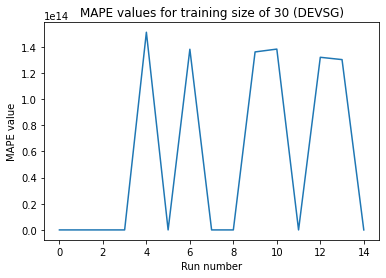

In [ ]:
plt.plot(mape_devsg[5], label="DEVSG")
plt.title(f"MAPE values for training size of {train_size} (DEVSG)")
plt.xlabel("Run number")
plt.ylabel("MAPE value")
plt.savefig("detailsmapede.pdf")
plt.show()

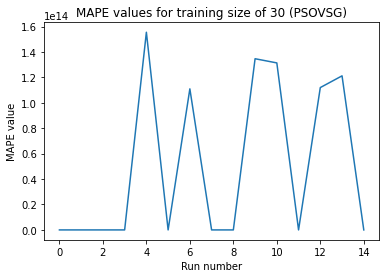

In [ ]:
plt.plot(mape_psovsg[5])
plt.title(f"MAPE values for training size of {train_size} (PSOVSG)")
plt.xlabel("Run number")
plt.ylabel("MAPE value")
plt.savefig("detailsmapepso.pdf")
plt.show()

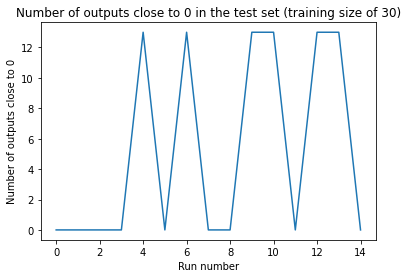

In [ ]:
plt.plot(nbr_y_zero[-1])
plt.title(f"Number of outputs close to 0 in the test set (training size of {train_size})")
plt.xlabel("Run number")
plt.ylabel("Number of outputs close to 0")
plt.savefig("detailsoutzero.pdf")
plt.show()